<a href="https://colab.research.google.com/github/aislam2346/aislam/blob/main/NYC_Taxi_Pipeline_Clean_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Section 1: Setup

In [20]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ── Imports ──────────────────────────────────────────────────────────────────
import duckdb
import pandas as pd
import numpy as np
import requests
import os
import hashlib
import json
import gc
import holidays
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
import joblib
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder


# ── Paths ─────────────────────────────────────────────────────────────────────
# Raw parquet files — where TLC files live on your Drive
PARQUET_DIR = Path("/content/drive/MyDrive/ODATA57078/nyc_taxi_parquet_files")

# Support files
ZONE_LOOKUP_PATH = Path("/content/drive/MyDrive/ODATA57078/taxi_zone_lookup.csv")

# Output folders — created automatically if missing
BASE     = Path("/content/drive/MyDrive/ODATA57078")
GOLD_DIR = BASE / "gold"          # one parquet per month, e.g. gold/2019-01.parquet
FEAT_DIR = BASE / "features"      # final modeling table
CKPT_DIR = BASE / "checkpoints"   # watermark.json lives here
OUT_DIR  = BASE / "eda_outputs"   # saved plots
MODEL_DIR = BASE / "models"       # saved models

for d in [GOLD_DIR, FEAT_DIR, CKPT_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── DuckDB — lives in /tmp, NOT on Drive ─────────────────────────────────────
# /tmp is wiped when Colab disconnects, which is fine
# gold parquet files on Drive are the real persistent storage.
DB_PATH = "/tmp/taxi_work.duckdb"

def get_connection():
    con = duckdb.connect(DB_PATH)
    con.execute("PRAGMA threads=4")
    con.execute("PRAGMA memory_limit='3GB'")
    return con

# ── Months to process ────────────────────────────────────────────────────────
# Add 2020 months here.
# The watermark means already-completed months are always skipped.
MONTHS_TO_INGEST = [
    '2019-01', '2019-02', '2019-03',
    '2019-04', '2019-05', '2019-06',
    '2019-07', '2019-08', '2019-09',
    '2019-10', '2019-11', '2019-12',
    # '2020-01', '2020-02', '2020-03',
    # '2020-04', '2020-05', '2020-06',
    # '2020-07', '2020-08', '2020-09',
    # '2020-10', '2020-11', '2020-12',
]

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130, 'axes.titlesize': 11, 'axes.labelsize': 9,
    'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#1a1a2e',
    'text.color': 'white', 'axes.labelcolor': 'white',
    'xtick.color': '#aaaaaa', 'ytick.color': '#aaaaaa',
})
COLORS = {
    'primary': '#4C9BE8', 'secondary': '#F5A623',
    'green': '#50C878',   'purple': '#A78BFA', 'red': '#E85D75',
}

print("Section 1 complete — paths and imports ready")
print(f"   GOLD_DIR : {GOLD_DIR}")
print(f"   DB_PATH  : {DB_PATH}  (local /tmp — not on Drive)")

Mounted at /content/drive
Section 1 complete — paths and imports ready
   GOLD_DIR : /content/drive/MyDrive/ODATA57078/gold
   DB_PATH  : /tmp/taxi_work.duckdb  (local /tmp — not on Drive)


## Section 2: Define Schema and Watermark

In [2]:
# ── Schema bootstrap ──────────────────────────────────────────────────────────
# raw_taxi_trips and staging_taxi_trips are TEMP tables — they exist only
# for the duration of processing one month, then disappear automatically.
# gold_hourly_demand and weather_hourly are permanent in /tmp DuckDB,
# but their durable copy is the parquet files on Drive.

def bootstrap_schema(con):
    """Create all tables. Safe to call every session — idempotent."""

    # Watermark — tracks what has been ingested (permanent, small)
    con.execute("""
        CREATE TABLE IF NOT EXISTS pipeline_watermark (
            file_name   VARCHAR PRIMARY KEY,
            file_month  VARCHAR,
            checksum    VARCHAR,
            row_count   BIGINT,
            ingested_at TIMESTAMP,
            layer       VARCHAR
        )
    """)

    # Raw — TEMP: holds one month of raw parquet data during processing
    # Dropped automatically when the connection closes
    con.execute("""
        CREATE TEMP TABLE IF NOT EXISTS raw_taxi_trips (
            VendorID              INTEGER,
            tpep_pickup_datetime  TIMESTAMP,
            tpep_dropoff_datetime TIMESTAMP,
            passenger_count       DOUBLE,
            trip_distance         DOUBLE,
            RatecodeID            DOUBLE,
            store_and_fwd_flag    VARCHAR,
            PULocationID          INTEGER,
            DOLocationID          INTEGER,
            payment_type          BIGINT,
            fare_amount           DOUBLE,
            extra                 DOUBLE,
            mta_tax               DOUBLE,
            tip_amount            DOUBLE,
            tolls_amount          DOUBLE,
            improvement_surcharge DOUBLE,
            total_amount          DOUBLE,
            congestion_surcharge  DOUBLE,
            airport_fee           DOUBLE,
            file_name             VARCHAR,
            file_month            VARCHAR,
            ingested_at           TIMESTAMP
        )
    """)

    # Staging — TEMP: holds one month of cleaned data during processing
    con.execute("""
        CREATE TEMP TABLE IF NOT EXISTS staging_taxi_trips (
            VendorID              INTEGER,
            tpep_pickup_datetime  TIMESTAMP,
            tpep_dropoff_datetime TIMESTAMP,
            passenger_count       INTEGER,
            trip_distance         DOUBLE,
            PULocationID          INTEGER,
            DOLocationID          INTEGER,
            payment_type          INTEGER,
            fare_amount           DOUBLE,
            tip_amount            DOUBLE,
            total_amount          DOUBLE,
            congestion_surcharge  DOUBLE,
            trip_duration_mins    DOUBLE,
            pickup_hour           INTEGER,
            pickup_dow            INTEGER,
            pickup_month          INTEGER,
            is_weekend            BOOLEAN,
            time_of_day           VARCHAR,
            file_month            VARCHAR,
            ingested_at           TIMESTAMP,
            rowhash               VARCHAR
        )
    """)

    # Gold — permanent in DuckDB session, but real persistence is parquet on Drive
    con.execute("""
        CREATE TABLE IF NOT EXISTS gold_hourly_demand (
            pickup_hour_ts       TIMESTAMP,
            file_month           VARCHAR,
            PULocationID         INTEGER,
            borough              VARCHAR,
            zone                 VARCHAR,
            trip_count           BIGINT,

            pct_card_payment     DOUBLE, -- pct of card payments
            pct_cash_payment     DOUBLE, -- pct of cash payments

            avg_trip_distance    DOUBLE,
            avg_fare_amount      DOUBLE,
            avg_duration_mins    DOUBLE,
            avg_passenger_count  DOUBLE,

            hour_of_day          INTEGER,
            day_of_week          INTEGER,
            is_weekend           BOOLEAN,
            is_holiday           BOOLEAN,
            temperature_2m       DOUBLE,
            precipitation        DOUBLE,
            snowfall             DOUBLE,
            windspeed_10m        DOUBLE,
            weathercode          INTEGER,
            is_snowing           BOOLEAN,
            is_raining           BOOLEAN,
            is_extreme_weather   BOOLEAN
        )
    """)

    # Weather — permanent in DuckDB session (fetched once from API)
    con.execute("""
        CREATE TABLE IF NOT EXISTS weather_hourly (
            weather_ts         TIMESTAMP PRIMARY KEY,
            temperature_2m     DOUBLE,
            precipitation      DOUBLE,
            snowfall           DOUBLE,
            windspeed_10m      DOUBLE,
            weathercode        INTEGER,
            is_snowing         BOOLEAN,
            is_raining         BOOLEAN,
            is_extreme_weather BOOLEAN
        )
    """)

    print("  Schema bootstrapped (idempotent)")

In [3]:
# ── Watermark — JSON on Drive, survives session restarts ──────────────────────
# Used to track ingestion progress - avoids re-ingestion of tables, and thus duplicates.
# The DuckDB watermark table above is kept as a within-session fast lookup.
# The JSON file on Drive is the source of truth across sessions.

WATERMARK_PATH = CKPT_DIR / "watermark.json"

def _load_watermark_json():
    """Load watermark from Drive JSON. Returns empty dict on first run."""
    if WATERMARK_PATH.exists():
        return json.loads(WATERMARK_PATH.read_text())
    return {}

def _save_watermark_json(wm: dict):
    """Persist watermark dict back to Drive JSON."""
    WATERMARK_PATH.write_text(json.dumps(wm, indent=2, default=str))

def file_checksum(path):
    """MD5 checksum of a file — detects if source data changed."""
    md5 = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(65536), b''):
            md5.update(chunk)
    return md5.hexdigest()

def is_already_ingested(con, file_name, checksum, layer):
    """
    Check Drive JSON watermark first (persists across sessions),
    then DuckDB watermark (fast within-session lookup).
    Returns True only if file_name + checksum + layer all match.
    """
    wm = _load_watermark_json()
    key = f"{layer}::{file_name}"
    if key in wm:
        if wm[key]['checksum'] == checksum:
            return True
        else:
            print(f"  Checksum changed for {file_name} — re-ingesting")
            return False
    # Fallback: check DuckDB watermark table
    result = con.execute(
        "SELECT checksum FROM pipeline_watermark WHERE file_name = ? AND layer = ?",
        [file_name, layer]
    ).fetchone()
    if result and result[0] == checksum:
        return True
    if result and result[0] != checksum:
        print(f"  Checksum changed for {file_name} — re-ingesting")
    return False

def mark_ingested(con, file_name, file_month, checksum, row_count, layer):
    """
    Write to both Drive JSON (persistent) and DuckDB table (fast lookup).
    """
    # Drive JSON — survives session restarts
    wm = _load_watermark_json()
    key = f"{layer}::{file_name}"
    wm[key] = {
        'file_name':   file_name,
        'file_month':  file_month,
        'checksum':    checksum,
        'row_count':   row_count,
        'ingested_at': str(datetime.now()),
        'layer':       layer,
    }
    _save_watermark_json(wm)

    # DuckDB table — fast within-session lookup
    con.execute("""
        INSERT INTO pipeline_watermark
            (file_name, file_month, checksum, row_count, ingested_at, layer)
        VALUES (?, ?, ?, ?, now(), ?)
        ON CONFLICT (file_name) DO UPDATE SET
            checksum    = excluded.checksum,
            row_count   = excluded.row_count,
            ingested_at = excluded.ingested_at,
            layer       = excluded.layer
    """, [file_name, file_month, checksum, row_count, layer])

def show_watermark():
    """Print all ingested files — useful for debugging and audit."""
    wm = _load_watermark_json()
    if not wm:
        print("  No watermark entries yet")
        return
    df = pd.DataFrame(wm.values()).sort_values(['layer', 'file_month'])
    display(df[['layer', 'file_month', 'file_name', 'row_count', 'ingested_at']])

print("Section 2 complete — schema and watermark functions ready")

Section 2 complete — schema and watermark functions ready


## Section 3: Define Ingestion Functions

In [4]:
# ── Layer 1: Raw ingestion ────────────────────────────────────────────────────
def ingest_raw(con, parquet_path, file_month):
    """
    Load one month parquet as-is into raw_taxi_trips TEMP table.
    Skips if gold parquet already exists on Drive AND has rows
    Otherwise, loads into TEMP table.
    """
    gold_path = GOLD_DIR / f"{file_month}.parquet"

    # Check if gold parquet exists and has rows in the watermark
    gold_watermark_record = con.execute(f"""
        SELECT row_count FROM pipeline_watermark
        WHERE file_month = '{file_month}' AND layer = 'gold'
    """).fetchone()

    if gold_watermark_record and gold_watermark_record[0] > 0:
        print(f"  {file_month}: gold parquet exists with {gold_watermark_record[0]:,} rows (per watermark) — skipping raw ingest and downstream steps")
        return False   # False = skip staging and gold too

    file_name = parquet_path.name
    checksum  = file_checksum(parquet_path)

    # Check if this raw file has already been processed and its raw data is still in TEMP table
    # This optimization prevents re-loading if it was done earlier in the same session
    current_temp_row_count = con.execute(
        "SELECT COUNT(*) FROM raw_taxi_trips WHERE file_month = ?", [file_month]
    ).fetchone()[0]

    if current_temp_row_count == 0: # If not in TEMP table, load it
        print(f"  Ingesting raw: {file_name}")
        con.execute("DELETE FROM raw_taxi_trips WHERE file_month = ?", [file_month]) # Ensure clean load

        con.execute(f"""
            INSERT INTO raw_taxi_trips
            SELECT
                VendorID, tpep_pickup_datetime, tpep_dropoff_datetime,
                passenger_count, trip_distance, RatecodeID, store_and_fwd_flag,
                PULocationID, DOLocationID, payment_type, fare_amount, extra,
                mta_tax, tip_amount, tolls_amount, improvement_surcharge,
                total_amount,
                TRY_CAST(congestion_surcharge AS DOUBLE),
                TRY_CAST(airport_fee          AS DOUBLE),
                '{file_name}'  AS file_name,
                '{file_month}' AS file_month,
                now()          AS ingested_at
            FROM read_parquet('{parquet_path}')
        """)

        row_count = con.execute(
            "SELECT COUNT(*) FROM raw_taxi_trips WHERE file_month = ?", [file_month]
        ).fetchone()[0]

        # Mark as ingested in persistent watermark, but it's for the raw file itself
        mark_ingested(con, file_name, file_month, checksum, row_count, layer='raw')
        print(f"  Raw  | {file_name} | {row_count:,} rows loaded into TEMP")
    else:
        print(f"  Raw data for {file_month} already present in TEMP table, skipping reload.")

    return True    # True = proceed to staging

In [5]:
# ── Layer 2: Staging ingestion ────────────────────────────────────────────────
def ingest_staging(con, file_month):
    """
    Promote one month raw → staging with cleaning rules:
      R1: Valid timestamps (non-null, pickup < dropoff, correct year)
      R2: Passenger count 1–6
      R3: Fare >= $2.50, total_amount > 0
      R4: Trip distance 0.1–50 miles
      R5: Trip duration 1–150 minutes
    Also computes rowhash for duplicate detection.
    """
    expected_year = int(file_month.split('-')[0])

    # Pre-cleaning audit — shows how many rows fail each rule
    df_audit = con.execute(f"""
        SELECT
            file_month,
            COUNT(*) AS total_rows,
            SUM(CASE WHEN tpep_pickup_datetime IS NULL
                      OR tpep_dropoff_datetime IS NULL
                      OR tpep_pickup_datetime >= tpep_dropoff_datetime
                      OR YEAR(tpep_pickup_datetime)  != {expected_year}
                      OR YEAR(tpep_dropoff_datetime) != {expected_year}
                                                         THEN 1 ELSE 0 END) AS bad_timestamps,
            SUM(CASE WHEN passenger_count IS NULL
                      OR passenger_count < 1
                      OR passenger_count > 6             THEN 1 ELSE 0 END) AS bad_passengers,
            SUM(CASE WHEN fare_amount IS NULL
                      OR fare_amount < 2.50
                      OR total_amount IS NULL
                      OR total_amount <= 0               THEN 1 ELSE 0 END) AS bad_fares,
            SUM(CASE WHEN trip_distance <= 0.1
                      OR trip_distance > 50              THEN 1 ELSE 0 END) AS bad_distance
        FROM raw_taxi_trips
        WHERE file_month = '{file_month}'
        GROUP BY file_month
    """).fetchdf()
    print(f"\n  Pre-cleaning audit for {file_month}:")
    display(df_audit)

    con.execute("DELETE FROM staging_taxi_trips WHERE file_month = ?", [file_month])

    con.execute(f"""
          INSERT INTO staging_taxi_trips
          WITH generated_staging_table AS (
              SELECT DISTINCT
                  VendorID, tpep_pickup_datetime, tpep_dropoff_datetime,
                  CAST(passenger_count AS INTEGER),
                  trip_distance,
                  PULocationID, DOLocationID,
                  CAST(payment_type AS INTEGER),
                  fare_amount, tip_amount, total_amount, congestion_surcharge,
                  DATEDIFF('minute', tpep_pickup_datetime, tpep_dropoff_datetime) AS trip_duration_mins,
                  HOUR(tpep_pickup_datetime)                        AS pickup_hour,
                  DAYOFWEEK(tpep_pickup_datetime)                   AS pickup_dow,
                  MONTH(tpep_pickup_datetime)                       AS pickup_month,
                  DAYOFWEEK(tpep_pickup_datetime) IN (0, 6)        AS is_weekend,
                  CASE
                      WHEN HOUR(tpep_pickup_datetime) BETWEEN 6  AND 11 THEN 'Morning'
                      WHEN HOUR(tpep_pickup_datetime) BETWEEN 12 AND 16 THEN 'Afternoon'
                      WHEN HOUR(tpep_pickup_datetime) BETWEEN 17 AND 21 THEN 'Evening'
                      ELSE 'Night'
                  END                                               AS time_of_day,
                  file_month,
                  ingested_at,
                  md5(
                      COALESCE(CAST(VendorID             AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(tpep_pickup_datetime AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(tpep_dropoff_datetime AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(PULocationID         AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(DOLocationID         AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(trip_distance        AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(fare_amount          AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(total_amount         AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(passenger_count      AS VARCHAR), '')
                  ) AS rowhash
              FROM raw_taxi_trips
              WHERE file_month = '{file_month}'
                AND tpep_pickup_datetime  IS NOT NULL
                AND tpep_dropoff_datetime IS NOT NULL
                AND tpep_pickup_datetime  < tpep_dropoff_datetime
                AND YEAR(tpep_pickup_datetime)  = {expected_year}
                AND YEAR(tpep_dropoff_datetime) = {expected_year}
                AND passenger_count IS NOT NULL
                AND passenger_count BETWEEN 1 AND 6
                AND fare_amount  IS NOT NULL
                AND fare_amount  >= 2.50
                AND total_amount IS NOT NULL
                AND total_amount >  0
                AND trip_distance BETWEEN 0.1 AND 50
                AND DATEDIFF('minute', tpep_pickup_datetime, tpep_dropoff_datetime) BETWEEN 1 AND 150
        )

        SELECT * FROM generated_staging_table
        WHERE rowhash NOT IN (
            SELECT DISTINCT rowhash FROM staging_taxi_trips
            WHERE file_month = '{file_month}')

    """)

    # Post-cleaning sense check
    df_sense = con.execute(f"""
        SELECT
            file_month,
            COUNT(*) AS staging_rows,
            (COUNT(rowhash) - COUNT(DISTINCT rowhash)) AS duplicate_hashes,
            SUM(CASE WHEN fare_amount < 2.50 THEN 1 ELSE 0 END) AS bad_fare_remaining,
            SUM(CASE WHEN passenger_count NOT BETWEEN 1 AND 6
                                              THEN 1 ELSE 0 END) AS bad_pax_remaining,
            SUM(CASE WHEN total_amount <= 0   THEN 1 ELSE 0 END) AS bad_total_remaining,
            SUM(CASE WHEN trip_duration_mins NOT BETWEEN 1 AND 150
                                              THEN 1 ELSE 0 END) AS bad_duration_remaining
        FROM staging_taxi_trips
        WHERE file_month = '{file_month}'
        GROUP BY file_month
    """).fetchdf()
    print(f"\n  Post-cleaning sense check for {file_month}:")
    display(df_sense)

    # Show up to 5 duplicate hashes for inspection
    df_dups = con.execute(f"""
        WITH dup_list AS (
            SELECT rowhash
            FROM staging_taxi_trips
            WHERE file_month = '{file_month}'
            GROUP BY rowhash HAVING COUNT(*) > 1
            LIMIT 5
        )
        SELECT * FROM staging_taxi_trips
        WHERE rowhash IN (SELECT rowhash FROM dup_list)
        ORDER BY rowhash
    """).fetchdf()
    if not df_dups.empty:
        print(f"  Duplicate hash sample for {file_month}:")
        display(df_dups)

    row_count = int(df_sense['staging_rows'].iloc[0]) if not df_sense.empty else 0
    print(f"  Staging | {file_month} | {row_count:,} rows")

    # ── Staging sample — persists a small per-trip slice for H2 drift analysis ──
    # Gold aggregates per-trip distributions away; we need raw rows for KS-test
    # and Wasserstein distance on trip_distance / fare_amount / trip_duration_mins.
    # 5000 rows per month = ~120k total across 24 months — negligible storage.
    STAGING_SAMPLE_PATH = BASE / "staging_sample" / f"{file_month}.parquet"
    STAGING_SAMPLE_PATH.parent.mkdir(parents=True, exist_ok=True)
    sample_cols = [
        'tpep_pickup_datetime', 'trip_distance', 'fare_amount',
        'trip_duration_mins', 'passenger_count', 'payment_type',
        'PULocationID', 'file_month',
    ]
    df_sample = con.execute(f"""
        SELECT {", ".join(sample_cols)}
        FROM staging_taxi_trips
        WHERE file_month = '{file_month}'
        USING SAMPLE 5000 ROWS
    """).fetchdf()
    df_sample.to_parquet(STAGING_SAMPLE_PATH, index=False)
    print(f"  Staging sample saved: {STAGING_SAMPLE_PATH.name} ({len(df_sample):,} rows)")

In [6]:
# ── Layer 3: Gold ingestion ───────────────────────────────────────────────────
def build_gold(con, file_month, zone_lookup_path=None):
    """
    Aggregate staging → gold at hourly grain per pickup zone.
    Joins weather_hourly (must be ingested first).
    Computes is_holiday in Python then passes to SQL (fixes all-False bug).
    Exports gold to Drive parquet and marks watermark.
    Grain: (pickup_hour_ts, PULocationID)
    """
    # Register zone lookup if not already loaded
    try:
        con.execute("SELECT 1 FROM taxi_zones LIMIT 1")
    except Exception:
        src = zone_lookup_path or str(ZONE_LOOKUP_PATH)
        df_zones = pd.read_csv(src)
        df_zones.columns = df_zones.columns.str.lower().str.strip()
        con.register('taxi_zones', df_zones)
        print(f"  Zone lookup registered: {len(df_zones)} zones")

    # Check weather data exists for this month
    weather_check = con.execute(f"""
        SELECT COUNT(*) FROM weather_hourly
        WHERE weather_ts BETWEEN '{file_month}-01'
                             AND '{file_month}-01'::DATE + INTERVAL 1 MONTH
    """).fetchone()[0]
    if weather_check == 0:
        print(f"  No weather data for {file_month} — run ingest_weather() first")
        return

    # ── is_holiday: computed in Python, passed to SQL as a temp table ─────────
    nyc_holidays = holidays.US(state='NY', years=[2019, 2020, 2021])
    df_holidays = pd.DataFrame({
        'holiday_date': [str(d) for d in nyc_holidays.keys()]
    })
    con.register('temp_holidays', df_holidays)

    con.execute("DELETE FROM gold_hourly_demand WHERE file_month = ?", [file_month])

    con.execute(f"""
        INSERT INTO gold_hourly_demand
        SELECT
            DATE_TRUNC('hour', s.tpep_pickup_datetime)              AS pickup_hour_ts,
            s.file_month,
            s.PULocationID,
            z.borough,
            z.zone,
            --s.payment_type, # We already have perentages instead of payment type
            COUNT(*)                                                AS trip_count,
            -- Payment mix: card share (payment_type=1) shifts post-COVID
            ROUND(AVG(CASE WHEN s.payment_type = 1
                           THEN 1.0 ELSE 0.0 END), 4)             AS pct_card_payment,
            -- Payment mix: card share (payment_type=2) shifts post-COVID
            ROUND(AVG(CASE WHEN s.payment_type = 2
                           THEN 1.0 ELSE 0.0 END), 4)             AS pct_cash_payment,
            ROUND(AVG(s.trip_distance),      4)                     AS avg_trip_distance,
            ROUND(AVG(s.fare_amount),        4)                     AS avg_fare_amount,
            ROUND(AVG(s.trip_duration_mins), 4)                     AS avg_duration_mins,
            ROUND(AVG(s.passenger_count),    4)                     AS avg_passenger_count,
            HOUR(s.tpep_pickup_datetime)                            AS hour_of_day,
            DAYOFWEEK(s.tpep_pickup_datetime)                       AS day_of_week,
            DAYOFWEEK(s.tpep_pickup_datetime) IN (0, 6)             AS is_weekend,
            CASE WHEN CAST(DATE_TRUNC('hour', s.tpep_pickup_datetime) AS DATE)::VARCHAR
                      IN (SELECT holiday_date FROM temp_holidays)
                 THEN TRUE ELSE FALSE END                           AS is_holiday,
            w.temperature_2m, w.precipitation, w.snowfall,
            w.windspeed_10m, w.weathercode,
            w.is_snowing, w.is_raining, w.is_extreme_weather
        FROM staging_taxi_trips s
        LEFT JOIN taxi_zones z    ON s.PULocationID = z.locationid
        LEFT JOIN weather_hourly w
               ON DATE_TRUNC('hour', s.tpep_pickup_datetime) = w.weather_ts
        WHERE s.file_month = '{file_month}'
          AND z.borough NOT IN ('EWR', 'Unknown')
        GROUP BY
            DATE_TRUNC('hour', s.tpep_pickup_datetime),
            s.file_month, s.PULocationID, z.borough, z.zone,s.payment_type,
            HOUR(s.tpep_pickup_datetime),
            DAYOFWEEK(s.tpep_pickup_datetime),
            DAYOFWEEK(s.tpep_pickup_datetime) IN (0, 6),
            w.temperature_2m, w.precipitation, w.snowfall,
            w.windspeed_10m, w.weathercode,
            w.is_snowing, w.is_raining, w.is_extreme_weather
    """)

    row_count = con.execute(
        "SELECT COUNT(*) FROM gold_hourly_demand WHERE file_month = ?", [file_month]
    ).fetchone()[0]
    print(f"  Gold | {file_month} | {row_count:,} hourly zone records")

    # ── Export to Drive parquet — the persistent copy ─────────────────────────
    gold_path = GOLD_DIR / f"{file_month}.parquet"
    con.execute(f"""
        COPY (SELECT * FROM gold_hourly_demand WHERE file_month = '{file_month}')
        TO '{gold_path}' (FORMAT PARQUET)
    """)
    print(f"  Saved: {gold_path}")

    # Mark gold as done in watermark (checksum = 'derived' since it's computed)
    file_name = f"yellow_tripdata_{file_month}.parquet"
    mark_ingested(con, file_name, file_month,
                  checksum='derived', row_count=row_count, layer='gold')

print(" Section 3 complete — ingestion functions ready")


 Section 3 complete — ingestion functions ready


## Section 4: Weather Ingestion

In [7]:
def ingest_weather(con, start_date='2019-01-01', end_date='2020-12-31'):
    """s
    Fetch hourly weather from Open-Meteo archive API for NYC.
    Watermark-based — resumes from last loaded hour if interrupted.

    Units: temperature_2m=°F, precipitation=mm, snowfall=cm, windspeed=km/h
    Extreme thresholds: snowfall > 7.62 cm OR precipitation > 25.4 mm
    """
    last_ts = con.execute("SELECT MAX(weather_ts) FROM weather_hourly").fetchone()[0]

    if last_ts is not None:
        fetch_from = str((last_ts + timedelta(hours=1)).date())
        if fetch_from > end_date:
            total = con.execute("SELECT COUNT(*) FROM weather_hourly").fetchone()[0]
            print(f"  Weather already loaded to {last_ts} ({total:,} hours)")
            return
        print(f"  Resuming weather from {fetch_from} → {end_date}")
    else:
        fetch_from = start_date
        print(f"  Fetching hourly weather {fetch_from} → {end_date}")

    resp = requests.get(
        'https://archive-api.open-meteo.com/v1/archive',
        params={
            'latitude': 40.7128, 'longitude': -74.0060,
            'start_date': fetch_from, 'end_date': end_date,
            'hourly': [
                'temperature_2m', 'precipitation', 'snowfall',
                'windspeed_10m', 'weathercode'
            ],
            'timezone': 'America/New_York',
            'temperature_unit': 'celsius',  # Temperature unit
            'windspeed_unit': 'kmh',           # Explicitly set km/h
            'precipitation_unit': 'mm'         # Explicitly set mm
        },
        timeout=60,
    )
    resp.raise_for_status()
    data = resp.json()

    df_w = pd.DataFrame({
        'weather_ts':    pd.to_datetime(data['hourly']['time']),
        'temperature_2m': data['hourly']['temperature_2m'],
        'precipitation':  data['hourly']['precipitation'],
        'snowfall':       data['hourly']['snowfall'],
        'windspeed_10m':  data['hourly']['windspeed_10m'],
        'weathercode':    data['hourly']['weathercode'],
    })

    df_w['is_snowing']         = df_w['snowfall']       > 7.62
    df_w['is_raining']         = df_w['precipitation']  > 0
    df_w['is_extreme_weather'] = (df_w['snowfall'] > 7.62) | (df_w['precipitation'] > 25.4)

    con.register('weather_staging', df_w)
    con.execute("""
        INSERT OR REPLACE INTO weather_hourly
        SELECT * FROM weather_staging
    """)
    con.unregister('weather_staging')

    total = con.execute("SELECT COUNT(*) FROM weather_hourly").fetchone()[0]
    print(f"  Weather loaded: {total:,} hours ({fetch_from} → {end_date})")

print(" Section 4 complete — weather function ready")

 Section 4 complete — weather function ready


## Section 5: Main Pipeline Loop

In [8]:
con = get_connection()

In [ ]:
con = get_connection()
bootstrap_schema(con)

# Fetch weather first — covers all months in one API call
ingest_weather(con, start_date='2019-01-01', end_date='2020-12-31')

PARQUET_DRIVE = PARQUET_DIR

for month in MONTHS_TO_INGEST:
    print(f"\n{'='*55}")
    print(f"  Processing: {month}")
    print(f"{'='*55}")

    parquet_path = PARQUET_DRIVE / f"yellow_tripdata_{month}.parquet"

    if not parquet_path.exists():
        print(f"  File not found: {parquet_path.name} — skipping")
        continue

    did_ingest = ingest_raw(con, parquet_path, month)

    if not did_ingest:
        # Gold already exists for this month — nothing to do
        continue

    ingest_staging(con, month)
    build_gold(con, file_month=month, zone_lookup_path=str(ZONE_LOOKUP_PATH))

    # ── Free memory: clear this month from raw + staging ─────────────────────
    # Gold is now safely in parquet on Drive — no need to keep these in DuckDB
    con.execute("DELETE FROM raw_taxi_trips    WHERE file_month = ?", [month])
    con.execute("DELETE FROM staging_taxi_trips WHERE file_month = ?", [month])
    con.execute("CHECKPOINT")
    gc.collect()
    print(f"  Memory cleared for {month}")

print("\n Pipeline complete")
print(f"   DuckDB size: {os.path.getsize(DB_PATH)/1024/1024:.1f} MB  (local /tmp)")

# Optional: view the full watermark log
show_watermark()

  Schema bootstrapped (idempotent)
  Weather already loaded to 2020-12-31 23:00:00 (17,544 hours)

  Processing: 2019-01
  Ingesting raw: yellow_tripdata_2019-01.parquet


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Raw  | yellow_tripdata_2019-01.parquet | 7,696,617 rows loaded into TEMP


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


  Pre-cleaning audit for 2019-01:


...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Staging | 2019-12 | 6,591,564 rows
  Staging sample saved: 2019-12.parquet (5,000 rows)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Gold | 2019-12 | 159,562 hourly zone records
  Saved: /content/drive/MyDrive/ODATA57078/gold/2019-12.parquet
  Memory cleared for 2019-12

 Pipeline complete
   DuckDB size: 95.8 MB  (local /tmp)


,layer,file_month,file_name,row_count,ingested_at
1,gold,2019-01,yellow_tripdata_2019-01.parquet,179217,2026-04-12 12:01:15.862046
3,gold,2019-02,yellow_tripdata_2019-02.parquet,167026,2026-04-12 12:02:33.233419
5,gold,2019-03,yellow_tripdata_2019-03.parquet,186016,2026-04-12 12:03:53.400263
7,gold,2019-04,yellow_tripdata_2019-04.parquet,172393,2026-04-12 12:05:09.347707
9,gold,2019-05,yellow_tripdata_2019-05.parquet,175316,2026-04-12 12:06:36.561904
11,gold,2019-06,yellow_tripdata_2019-06.parquet,170369,2026-04-12 12:07:56.559312
13,gold,2019-07,yellow_tripdata_2019-07.parquet,167702,2026-04-12 12:09:01.049371
15,gold,2019-08,yellow_tripdata_2019-08.parquet,163628,2026-04-12 12:10:03.509754
17,gold,2019-09,yellow_tripdata_2019-09.parquet,159815,2026-04-12 12:11:09.392103
19,gold,2019-10,yellow_tripdata_2019-10.parquet,162294,2026-04-12 12:12:46.317129


In [ ]:
# Load one of the generated gold parquet files to inspect its content
# For example, let's look at the 'yellow_tripdata_2020-01.parquet' file.

gold_example_path = GOLD_DIR / "2020-01.parquet"

if gold_example_path.exists():
    df_example = pd.read_parquet(gold_example_path)
    print(f"\n--- Preview of {gold_example_path.name} ---")
    print("df_example.head():")
    display(df_example.head())

    print("\ndf_example.info():")
    df_example.info()

    print("\nColumns in this parquet file:")
    print(df_example.columns.tolist())
else:
    print(f"Warning: {gold_example_path.name} not found. Please ensure Section 5 (Main Pipeline Loop) has been run successfully to generate gold parquet files.")


--- Preview of 2020-01.parquet ---
df_example.head():


,pickup_hour_ts,file_month,PULocationID,borough,zone,trip_count,pct_card_payment,pct_cash_payment,avg_trip_distance,avg_fare_amount,...,is_weekend,is_holiday,temperature_2m,precipitation,snowfall,windspeed_10m,weathercode,is_snowing,is_raining,is_extreme_weather
0,2020-01-09 19:00:00,2020-01,142,Manhattan,Lincoln Square East,286,1.0,0.0,1.8549,9.1958,...,False,False,-0.5,0.0,0.0,7.6,3,False,False,False
1,2020-01-09 21:00:00,2020-01,230,Manhattan,Times Sq/Theatre District,550,1.0,0.0,2.6863,12.0409,...,False,False,-0.9,0.0,0.0,5.8,3,False,False,False
2,2020-01-09 22:00:00,2020-01,161,Manhattan,Midtown Center,595,1.0,0.0,2.6586,11.4496,...,False,False,-0.6,0.0,0.0,8.4,3,False,False,False
3,2020-01-10 09:00:00,2020-01,233,Manhattan,UN/Turtle Bay South,142,1.0,0.0,2.2375,11.8089,...,False,False,2.2,0.0,0.0,17.9,3,False,False,False
4,2020-01-10 10:00:00,2020-01,236,Manhattan,Upper East Side North,490,1.0,0.0,1.8459,10.0684,...,False,False,3.3,0.0,0.0,17.7,3,False,False,False



df_example.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151997 entries, 0 to 151996
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   pickup_hour_ts       151997 non-null  datetime64[us]
 1   file_month           151997 non-null  object        
 2   PULocationID         151997 non-null  int32         
 3   borough              151997 non-null  object        
 4   zone                 151997 non-null  object        
 5   trip_count           151997 non-null  int64         
 6   pct_card_payment     151997 non-null  float64       
 7   pct_cash_payment     151997 non-null  float64       
 8   avg_trip_distance    151997 non-null  float64       
 9   avg_fare_amount      151997 non-null  float64       
 10  avg_duration_mins    151997 non-null  float64       
 11  avg_passenger_count  151997 non-null  float64       
 12  hour_of_day          151997 non-null  int32         

## Section 6: Load Gold data and build Features for modelling

In [30]:
def load_gold(months):
    """
    Load gold parquet files from Drive for the given months.
    Returns a combined pandas DataFrame sorted by zone and timestamp.

    Emits a warning if any parquet is missing columns from CURRENT_GOLD_COLUMNS
    — run migrate_gold_schema() and re-run the pipeline to fix this.
    """
    frames = []
    for m in months:
        path = GOLD_DIR / f"{m}.parquet"
        if path.exists():
            df_m = pd.read_parquet(path)
            frames.append(df_m)
        else:
            print(f"  Warning: {m}.parquet not found \u2014 run pipeline first")
    if not frames:
        raise FileNotFoundError("No gold parquet files found. Run Section 5 first.")
    df = pd.concat(frames, ignore_index=True)
    df['pickup_hour_ts'] = pd.to_datetime(df['pickup_hour_ts'])
    df = df.sort_values(['zone', 'pickup_hour_ts']).reset_index(drop=True)
    print(f"  Loaded {len(df):,} rows across {len(frames)} months")
    return df


def build_lag_features(df,
                       location_col='zone',
                       datetime_col='pickup_hour_ts',
                       demand_col='trip_count'):
    """
    Add lag and rolling-style time features to the gold DataFrame.

    Important:
    - Must be called on the FULL dataset so lag features can cross month boundaries.
    - Missing hours per zone are filled with 0 trips via a complete hourly spine.
    - Avoids backward-filling weather-like variables to reduce future leakage.
    """

    # Make a copy so the original dataframe is not modified in-place
    df = df.copy()

    # Check for duplicate zone-hour rows before reindexing
    dup_mask = df.duplicated(subset=[location_col, datetime_col], keep=False)
    df_duplicates = df[dup_mask]

    if not df_duplicates.empty:
        print(
            f"  Warning: Found {len(df_duplicates)} duplicate rows for "
            f"{location_col} and {datetime_col}. Showing first 10:"
        )
        display(df_duplicates.head(10))
        print("  Aggregating duplicates by group...")

        # Aggregate duplicate rows into a single zone-hour record
        # Counts should sum; proportions and continuous values are averaged.
        agg_funcs = {
            'trip_count': 'sum',
            'pct_card_payment': 'mean',
            'pct_cash_payment': 'mean',
            'avg_trip_distance': 'mean',
            'avg_fare_amount': 'mean',
            'avg_duration_mins': 'mean',
            'avg_passenger_count': 'mean',
            'temperature_2m': 'mean',
            'precipitation': 'mean',
            'snowfall': 'mean',
            'windspeed_10m': 'mean',
            'is_weekend': 'max',
            'is_holiday': 'max',
            'is_snowing': 'max',
            'is_raining': 'max',
            'is_extreme_weather': 'max',
            'borough': 'first',
            'weathercode': 'first',
            'file_month': 'first',
            'hour_of_day': 'first',
            'day_of_week': 'first'
        }

        # Keep only the columns that actually exist in the dataframe
        agg_funcs = {k: v for k, v in agg_funcs.items() if k in df.columns}

        df = df.groupby([location_col, datetime_col], as_index=False).agg(agg_funcs)
        print(f"  Aggregated to {len(df):,} unique rows.")

    # Build a complete hourly spine across all zones and hours
    all_hours = pd.date_range(df[datetime_col].min(), df[datetime_col].max(), freq='h')
    all_zones = df[location_col].unique()

    spine = pd.MultiIndex.from_product(
        [all_zones, all_hours],
        names=[location_col, datetime_col]
    )

    # Reindex onto the full zone-hour grid
    df = (
        df.set_index([location_col, datetime_col])
          .reindex(spine)
          .reset_index()
    )

    # Hours with no trips are true zero-demand hours
    df[demand_col] = df[demand_col].fillna(0)

    # Recreate deterministic time features from timestamp
    df['hour_of_day'] = df[datetime_col].dt.hour
    df['day_of_week'] = df[datetime_col].dt.dayofweek
    df['month_of_year'] = df[datetime_col].dt.month
    df['is_weekend'] = df[datetime_col].dt.dayofweek.isin([5, 6])

    # Sort before group-based fills and lags
    df = df.sort_values([location_col, datetime_col]).reset_index(drop=True)

    # Fill weather / holiday fields within each zone using only past values
    # Avoid bfill because it can leak future information backward in time.
    weather_cols = [
        'temperature_2m', 'precipitation', 'snowfall', 'windspeed_10m',
        'weathercode', 'is_snowing', 'is_raining', 'is_extreme_weather',
        'is_holiday', 'borough'
    ]
    weather_cols = [c for c in weather_cols if c in df.columns]

    if weather_cols:
        df[weather_cols] = (
            df.groupby(location_col)[weather_cols]
              .transform(lambda x: x.ffill())
        )

    # If a zone starts with missing weather values, use within-zone backfill only
    # as a last resort for the leading edge, not for general imputation.
    if weather_cols:
        df[weather_cols] = (
            df.groupby(location_col)[weather_cols]
              .transform(lambda x: x.ffill().bfill())
        )

    # Payment mix is undefined when there are no trips, so set zero explicitly
    if 'pct_card_payment' in df.columns:
        df['pct_card_payment'] = df['pct_card_payment'].fillna(0)

    if 'pct_cash_payment' in df.columns:
        df['pct_cash_payment'] = df['pct_cash_payment'].fillna(0)

    # Re-derive file_month from the timestamp so it stays consistent
    df['file_month'] = df[datetime_col].dt.to_period('M').astype(str)

    # Create lag features within each zone so values do not bleed across zones
    grp = df.groupby(location_col)[demand_col]
    df['lag_1h'] = grp.shift(1)
    df['lag_24h'] = grp.shift(24)
    df['lag_168h'] = grp.shift(168)

    print(f"  Lag features built — {len(df):,} rows (includes spine fill)")
    return df

Then build features

In [31]:
# ── Load and build features ───────────────────────────────────────────────────
TRAIN_MONTHS = [
    '2019-01', '2019-02', '2019-03', '2019-04', '2019-05', '2019-06',
    '2019-07', '2019-08', '2019-09','2019-10', '2019-11', '2019-12',
    # '2020-01','2020-02','2020-03','2020-04','2020-05','2020-06',
    # '2020-07','2020-08','2020-09','2020-10','2020-11','2020-12'
]

df_gold = load_gold(TRAIN_MONTHS)

print("\n--- Preview of df_gold after loading from parquet, before lag feature creation ---")
print("df_gold.head():")
display(df_gold.head())

print("\ndf_gold.info():")
df_gold.info()

print("\ndf_gold.describe():")
display(df_gold.describe())
print("----------------------------------------------------------------------------------")

df_gold = build_lag_features(df_gold)

#Drop first 168h per zone — these have unavoidably NaN lags
df_gold = df_gold.dropna(subset=['lag_168h'])

print(f"\n  Final modelling rows: {len(df_gold):,}")
print(f"  Columns: {list(df_gold.columns)}")

# Optional: save features to Drive so you don't have to rebuild each session
feat_path = FEAT_DIR / "features_train.parquet"
df_gold.to_parquet(feat_path, index=False)
print(f"\n  Features saved: {feat_path}")

print(" Section 6 complete — df_gold ready for modelling")

  Loaded 2,019,121 rows across 12 months

--- Preview of df_gold after loading from parquet, before lag feature creation ---
df_gold.head():


,pickup_hour_ts,file_month,PULocationID,borough,zone,trip_count,pct_card_payment,pct_cash_payment,avg_trip_distance,avg_fare_amount,...,is_weekend,is_holiday,temperature_2m,precipitation,snowfall,windspeed_10m,weathercode,is_snowing,is_raining,is_extreme_weather
0,2019-01-01 10:00:00,2019-01,3,Bronx,Allerton/Pelham Gardens,2,1.0,0.0,11.18,30.92,...,False,True,14.2,0.0,0.0,32.0,3,False,False,False
1,2019-01-02 08:00:00,2019-01,3,Bronx,Allerton/Pelham Gardens,1,1.0,0.0,7.20,26.99,...,False,False,0.7,0.0,0.0,7.7,3,False,False,False
2,2019-01-02 13:00:00,2019-01,3,Bronx,Allerton/Pelham Gardens,1,0.0,1.0,10.20,30.50,...,False,False,3.2,0.0,0.0,3.3,3,False,False,False
3,2019-01-03 09:00:00,2019-01,3,Bronx,Allerton/Pelham Gardens,1,1.0,0.0,12.45,36.51,...,False,False,4.8,0.0,0.0,12.6,3,False,False,False
4,2019-01-03 12:00:00,2019-01,3,Bronx,Allerton/Pelham Gardens,1,1.0,0.0,7.39,30.03,...,False,False,6.9,0.0,0.0,22.7,3,False,False,False



df_gold.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2019121 entries, 0 to 2019120
Data columns (total 24 columns):
 #   Column               Dtype         
---  ------               -----         
 0   pickup_hour_ts       datetime64[us]
 1   file_month           object        
 2   PULocationID         int32         
 3   borough              object        
 4   zone                 object        
 5   trip_count           int64         
 6   pct_card_payment     float64       
 7   pct_cash_payment     float64       
 8   avg_trip_distance    float64       
 9   avg_fare_amount      float64       
 10  avg_duration_mins    float64       
 11  avg_passenger_count  float64       
 12  hour_of_day          int32         
 13  day_of_week          int32         
 14  is_weekend           bool          
 15  is_holiday           bool          
 16  temperature_2m       float64       
 17  precipitation        float64       
 18  snowfall             float64       
 19  wind

,pickup_hour_ts,PULocationID,trip_count,pct_card_payment,pct_cash_payment,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,hour_of_day,day_of_week,temperature_2m,precipitation,snowfall,windspeed_10m,weathercode
count,2019121,2.019121e+06,2.019121e+06,2.019121e+06,2.019121e+06,2.019121e+06,2.019121e+06,2.019121e+06,2.019121e+06,2.019121e+06,2.019121e+06,2.019121e+06,2.019121e+06,2.019121e+06,2.019121e+06,2.019121e+06
mean,2019-06-27 06:04:08.484959,1.420649e+02,3.991166e+01,4.769585e-01,3.953156e-01,3.933858e+00,1.671146e+01,1.572266e+01,1.536864e+00,1.201291e+01,3.026056e+00,1.211362e+01,1.539577e-01,6.836534e-03,1.375848e+01,1.141042e+01
min,2019-01-01 00:00:00,2.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e-01,2.500000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-1.650000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2019-03-27 13:00:00,7.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,1.866000e+00,9.500000e+00,9.826100e+00,1.000000e+00,7.000000e+00,1.000000e+00,3.700000e+00,0.000000e+00,0.000000e+00,8.300000e+00,0.000000e+00
50%,2019-06-23 18:00:00,1.430000e+02,5.000000e+00,0.000000e+00,0.000000e+00,2.602500e+00,1.185710e+01,1.300000e+01,1.493300e+00,1.200000e+01,3.000000e+00,1.240000e+01,0.000000e+00,0.000000e+00,1.230000e+01,3.000000e+00
75%,2019-09-25 23:00:00,2.160000e+02,4.000000e+01,1.000000e+00,1.000000e+00,4.330000e+00,1.700000e+01,1.800000e+01,1.729900e+00,1.800000e+01,5.000000e+00,2.070000e+01,0.000000e+00,0.000000e+00,1.790000e+01,3.000000e+00
max,2019-12-31 23:00:00,2.630000e+02,1.734000e+03,1.000000e+00,1.000000e+00,5.000000e+01,6.711231e+05,1.500000e+02,6.000000e+00,2.300000e+01,6.000000e+00,3.520000e+01,9.400000e+00,3.080000e+00,4.990000e+01,7.500000e+01
std,NaN,7.484935e+01,7.969860e+01,4.994689e-01,4.889185e-01,3.861673e+00,5.103028e+02,1.073826e+01,6.677358e-01,6.731784e+00,2.010741e+00,1.008623e+01,5.713932e-01,7.893365e-02,7.204896e+00,2.106660e+01


----------------------------------------------------------------------------------


,pickup_hour_ts,file_month,PULocationID,borough,zone,trip_count,pct_card_payment,pct_cash_payment,avg_trip_distance,avg_fare_amount,...,is_weekend,is_holiday,temperature_2m,precipitation,snowfall,windspeed_10m,weathercode,is_snowing,is_raining,is_extreme_weather
19,2019-01-06 18:00:00,2019-01,3,Bronx,Allerton/Pelham Gardens,1,0.0,1.0,0.16,3.00,...,True,False,4.5,0.0,0.0,19.7,3,False,False,False
20,2019-01-06 18:00:00,2019-01,3,Bronx,Allerton/Pelham Gardens,1,1.0,0.0,7.77,24.88,...,True,False,4.5,0.0,0.0,19.7,3,False,False,False
57,2019-01-14 08:00:00,2019-01,3,Bronx,Allerton/Pelham Gardens,1,0.0,1.0,1.73,8.00,...,False,False,-6.0,0.0,0.0,19.4,2,False,False,False
58,2019-01-14 08:00:00,2019-01,3,Bronx,Allerton/Pelham Gardens,1,1.0,0.0,10.97,53.00,...,False,False,-6.0,0.0,0.0,19.4,2,False,False,False
88,2019-01-22 07:00:00,2019-01,3,Bronx,Allerton/Pelham Gardens,2,1.0,0.0,6.82,26.75,...,False,False,-10.6,0.0,0.0,21.8,0,False,False,False
89,2019-01-22 07:00:00,2019-01,3,Bronx,Allerton/Pelham Gardens,1,0.0,1.0,14.40,38.76,...,False,False,-10.6,0.0,0.0,21.8,0,False,False,False
118,2019-01-29 06:00:00,2019-01,3,Bronx,Allerton/Pelham Gardens,1,0.0,1.0,16.40,48.00,...,False,False,-4.6,0.0,0.0,6.6,2,False,False,False
119,2019-01-29 06:00:00,2019-01,3,Bronx,Allerton/Pelham Gardens,1,1.0,0.0,12.94,44.00,...,False,False,-4.6,0.0,0.0,6.6,2,False,False,False
132,2019-01-31 14:00:00,2019-01,3,Bronx,Allerton/Pelham Gardens,1,0.0,1.0,0.53,4.00,...,False,False,-9.1,0.0,0.0,18.9,0,False,False,False
133,2019-01-31 14:00:00,2019-01,3,Bronx,Allerton/Pelham Gardens,1,1.0,0.0,10.00,29.50,...,False,False,-9.1,0.0,0.0,18.9,0,False,False,False


  Aggregating duplicates by group...
  Aggregated to 1,062,748 unique rows.


/tmp/ipykernel_3611/643555726.py:126: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda x: x.ffill())
/tmp/ipykernel_3611/643555726.py:134: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda x: x.ffill().bfill())


  Lag features built — 2,260,080 rows (includes spine fill)

  Final modelling rows: 2,216,736
  Columns: ['zone', 'pickup_hour_ts', 'trip_count', 'pct_card_payment', 'pct_cash_payment', 'avg_trip_distance', 'avg_fare_amount', 'avg_duration_mins', 'avg_passenger_count', 'temperature_2m', 'precipitation', 'snowfall', 'windspeed_10m', 'is_weekend', 'is_holiday', 'is_snowing', 'is_raining', 'is_extreme_weather', 'borough', 'weathercode', 'file_month', 'hour_of_day', 'day_of_week', 'month_of_year', 'lag_1h', 'lag_24h', 'lag_168h']

  Features saved: /content/drive/MyDrive/ODATA57078/features/features_train.parquet
 Section 6 complete — df_gold ready for modelling


### Data Preview: `df_gold` DataFrame

In [11]:
# Display the first 5 rows of df_gold
print("df_gold.head():")
display(df_gold.head())

df_gold.head():


,zone,pickup_hour_ts,trip_count,pct_card_payment,pct_cash_payment,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,temperature_2m,...,is_raining,is_extreme_weather,borough,weathercode,file_month,hour_of_day,day_of_week,lag_1h,lag_24h,lag_168h
168,Allerton/Pelham Gardens,2019-01-08 00:00:00,0.0,0.0,0.0,NaN,NaN,NaN,NaN,-1.0,...,False,False,Bronx,3.0,2019-01,0,1,0.0,0.0,0.0
169,Allerton/Pelham Gardens,2019-01-08 01:00:00,0.0,0.0,0.0,NaN,NaN,NaN,NaN,-1.0,...,False,False,Bronx,3.0,2019-01,1,1,0.0,0.0,0.0
170,Allerton/Pelham Gardens,2019-01-08 02:00:00,0.0,0.0,0.0,NaN,NaN,NaN,NaN,-1.0,...,False,False,Bronx,3.0,2019-01,2,1,0.0,0.0,0.0
171,Allerton/Pelham Gardens,2019-01-08 03:00:00,0.0,0.0,0.0,NaN,NaN,NaN,NaN,-1.0,...,False,False,Bronx,3.0,2019-01,3,1,0.0,0.0,0.0
172,Allerton/Pelham Gardens,2019-01-08 04:00:00,0.0,0.0,0.0,NaN,NaN,NaN,NaN,-1.0,...,False,False,Bronx,3.0,2019-01,4,1,0.0,0.0,0.0


In [12]:
# Display information about df_gold, including data types and non-null counts
print("df_gold.info():")
df_gold.info()

df_gold.info():
<class 'pandas.core.frame.DataFrame'>
Index: 2216736 entries, 168 to 2260079
Data columns (total 26 columns):
 #   Column               Dtype         
---  ------               -----         
 0   zone                 object        
 1   pickup_hour_ts       datetime64[ns]
 2   trip_count           float64       
 3   pct_card_payment     float64       
 4   pct_cash_payment     float64       
 5   avg_trip_distance    float64       
 6   avg_fare_amount      float64       
 7   avg_duration_mins    float64       
 8   avg_passenger_count  float64       
 9   temperature_2m       float64       
 10  precipitation        float64       
 11  snowfall             float64       
 12  windspeed_10m        float64       
 13  is_weekend           bool          
 14  is_holiday           bool          
 15  is_snowing           bool          
 16  is_raining           bool          
 17  is_extreme_weather   bool          
 18  borough              object        
 19  weatherc

In [13]:
# Display summary statistics for numerical columns in df_gold
print("df_gold.describe():")
display(df_gold.describe())

df_gold.describe():


,pickup_hour_ts,trip_count,pct_card_payment,pct_cash_payment,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,temperature_2m,precipitation,snowfall,windspeed_10m,weathercode,hour_of_day,day_of_week,lag_1h,lag_24h,lag_168h
count,2216736,2.216736e+06,2.216736e+06,2.216736e+06,1.040324e+06,1.040324e+06,1.040324e+06,1.040324e+06,2.216736e+06,2.216736e+06,2.216736e+06,2.216736e+06,2.216736e+06,2.216736e+06,2.216736e+06,2.216736e+06,2.216736e+06,2.216736e+06
mean,2019-07-05 23:30:00.000000256,3.569987e+01,2.524447e-01,1.806118e-01,4.444760e+00,1.817950e+01,1.701178e+01,1.531288e+00,1.267904e+01,1.531191e-01,6.511502e-03,1.387648e+01,1.152740e+01,1.150000e+01,2.994413e+00,3.569982e+01,3.572579e+01,3.588373e+01
min,2019-01-08 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e-01,2.500000e+00,1.000000e+00,1.000000e+00,-1.650000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2019-04-07 11:45:00,0.000000e+00,0.000000e+00,0.000000e+00,2.036850e+00,1.000000e+01,1.026455e+01,1.000000e+00,4.100000e+00,0.000000e+00,0.000000e+00,8.400000e+00,0.000000e+00,5.750000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2019-07-05 23:30:00,0.000000e+00,0.000000e+00,0.000000e+00,2.929500e+00,1.269465e+01,1.350455e+01,1.433433e+00,1.330000e+01,0.000000e+00,0.000000e+00,1.260000e+01,3.000000e+00,1.150000e+01,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2019-10-03 11:15:00,7.000000e+00,5.000000e-01,5.000000e-01,4.958000e+00,1.950000e+01,1.937500e+01,1.698850e+00,2.120000e+01,0.000000e+00,0.000000e+00,1.800000e+01,3.000000e+00,1.725000e+01,5.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00
max,2019-12-31 23:00:00,1.965000e+03,1.000000e+00,1.000000e+00,5.000000e+01,1.678000e+05,1.500000e+02,6.000000e+00,3.520000e+01,9.400000e+00,3.080000e+00,4.990000e+01,7.500000e+01,2.300000e+01,6.000000e+00,1.965000e+03,1.965000e+03,1.965000e+03
std,NaN,1.005594e+02,3.382280e-01,2.716411e-01,4.185812e+00,1.845475e+02,1.154979e+01,6.624488e-01,1.015744e+01,5.631579e-01,7.414670e-02,7.191755e+00,2.115421e+01,6.922188e+00,1.999993e+00,1.005596e+02,1.006323e+02,1.009216e+02


In [ ]:
# df_gold.info()

In [ ]:
print("\nNaN values per column in df_gold (before dropping rows for lag_168h):\n")
# Load df_gold again to see NaNs *before* the final dropna in JBH7OkTq8DKe
# This is for diagnostic purposes, the actual df_gold used for modeling will have these dropped.
# df_gold_temp_for_nan_check = load_gold(TRAIN_MONTHS)
# df_gold_temp_for_nan_check = build_lag_features(df_gold_temp_for_nan_check)

display(df_gold.isnull().sum().sort_values(ascending=False))


NaN values per column in df_gold (before dropping rows for lag_168h):



,0
avg_passenger_count,1176412
avg_trip_distance,1176412
avg_duration_mins,1176412
avg_fare_amount,1176412
pickup_hour_ts,0
zone,0
pct_cash_payment,0
pct_card_payment,0
trip_count,0
temperature_2m,0


## Section 7: Baseline Modelling

# New Section

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. Prepare modeling dataframe
# ─────────────────────────────────────────────────────────────────────────────

# Make a copy so we can safely add/modify columns without warnings
df_gold = df_gold.copy()

# Sort chronologically for time-series modeling
df_model = df_gold.sort_values('pickup_hour_ts').reset_index(drop=True)

# Add month_of_year here so it exists before we select FEATURES
if 'month_of_year' not in df_model.columns:
    df_model['month_of_year'] = df_model['pickup_hour_ts'].dt.month

# Ensure zone exists as a feature and is treated as categorical
df_model['zone'] = df_model['zone'].astype('category')

# Log-transform target to stabilize variance
df_model['trip_count_log'] = np.log1p(df_model['trip_count'])

# Log-transform skewed numeric features
for col in ['lag_1h', 'lag_24h', 'lag_168h', 'precipitation', 'snowfall']:
    df_model[f'{col}_log'] = np.log1p(df_model[col])


# ─────────────────────────────────────────────────────────────────────────────
# 2. Define features and target
# ─────────────────────────────────────────────────────────────────────────────

FEATURES = [
    'zone',
    'hour_of_day', 'day_of_week', 'month_of_year',
    'is_weekend', 'is_holiday', 'is_snowing', 'is_raining', 'is_extreme_weather',
    'temperature_2m', 'precipitation_log', 'snowfall_log', 'windspeed_10m',
    'pct_card_payment',
    'lag_1h_log', 'lag_24h_log', 'lag_168h_log',
]

TARGET = 'trip_count_log'


# ─────────────────────────────────────────────────────────────────────────────
# 3. Time-based split
# ─────────────────────────────────────────────────────────────────────────────

# Use a chronological split to avoid leakage
TRAIN_END = '2019-09-30 23:59:00'
VAL_START  = '2019-10-01 00:00:00'
VAL_END    = '2019-12-31 23:59:00'

train = df_model[df_model['pickup_hour_ts'] <= TRAIN_END].copy()
val   = df_model[(df_model['pickup_hour_ts'] >= VAL_START) &
                 (df_model['pickup_hour_ts'] <= VAL_END)].copy()

X_train, y_train = train[FEATURES].copy(), train[TARGET].copy()
X_val,   y_val   = val[FEATURES].copy(),   val[TARGET].copy()


# ─────────────────────────────────────────────────────────────────────────────
# 4. Cast categorical and boolean columns
# ─────────────────────────────────────────────────────────────────────────────

# LightGBM can use categorical features directly if they are dtype 'category'
categorical_cols = [
    'zone', 'hour_of_day', 'day_of_week', 'month_of_year',
    'is_weekend', 'is_holiday', 'is_snowing', 'is_raining', 'is_extreme_weather'
]

for col in categorical_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('category')
        X_val[col] = X_val[col].astype('category')

# Optional: keep binary flags as bool if you prefer
boolean_features = ['is_weekend', 'is_holiday', 'is_snowing', 'is_raining', 'is_extreme_weather']
for col in boolean_features:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna(False).astype(bool)
        X_val[col] = X_val[col].fillna(False).astype(bool)


# ─────────────────────────────────────────────────────────────────────────────
# 5. Train LightGBM model
# ─────────────────────────────────────────────────────────────────────────────

params = {
    'objective': 'regression',
    'metric': 'mae',
    'n_estimators': 2000,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'verbose': -1,
}

model = lgb.LGBMRegressor(**params)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    categorical_feature=[c for c in categorical_cols if c in X_train.columns],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100),
    ]
)

print("Section 7 complete — baseline model trained")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 0.131974
[200]	valid_0's l1: 0.124895
[300]	valid_0's l1: 0.124096
[400]	valid_0's l1: 0.123749
Early stopping, best iteration is:
[448]	valid_0's l1: 0.123668
Section 7 complete — baseline model trained


In [33]:
# ── After predicting, inverse-transform to get real trip counts ───────────────

val_preds_log = model.predict(X_val)
val_preds = np.expm1(val_preds_log)          # back to original scale
val_actuals = np.expm1(y_val)                # y_val was fit on log scale

# ── Evaluate on original scale ─────────────────────────────────────────────────

mae  = np.mean(np.abs(val_preds - val_actuals))
mape = np.mean(np.abs((val_actuals - val_preds) / val_actuals)) * 100
rmse = np.sqrt(np.mean((val_preds - val_actuals) ** 2))
mean_demand = val_actuals.mean()
total_actual = np.sum(val_actuals)

# WMAPE avoids the division by zero problem
wmape = (np.sum(np.abs(val_actuals - val_preds)) / total_actual) * 100 if total_actual > 0 else 0

print(f"MAE:            {mae:.3f} trips")
print(f"WMAPE:          {wmape:.3f}%")
print(f"RMSE:           {rmse:.3f} trips")
print(f"Normalised MAE: {mae / mean_demand * 100:.3f}%")
print(f"Mean demand:    {mean_demand:.2f} trips/hr")

MAE:            4.292 trips
WMAPE:          12.263%
RMSE:           14.844 trips
Normalised MAE: 12.263%
Mean demand:    35.00 trips/hr


In [35]:
# Calculate residuals to see which entries are experiencing big misses

# First, add the predictions to the validation DataFrame
val = val.copy()
val['y_pred'] = val_preds

# Calculate absolute and squared errors
val['abs_error'] = np.abs(val['trip_count'] - val['y_pred'])
val['squared_error'] = (val['trip_count'] - val['y_pred']) ** 2

# 1. Aggregate errors by zone
zone_diag = val.groupby('zone').agg(
    avg_demand=('trip_count', 'mean'),
    zone_mae=('abs_error', 'mean'),
    zone_rmse=('squared_error', lambda x: np.sqrt(x.mean())),
    count=('trip_count', 'count')
).reset_index()

# 2. Calculate the 'Volatility Ratio' (RMSE/MAE)
# A ratio > 2.0 usually indicates high-variance outliers (spikes)
zone_diag['volatility_ratio'] = zone_diag['zone_rmse'] / zone_diag['zone_mae']

# 3. Sort by total contribution to RMSE
# This identifies the zones that are "pulling" your global RMSE up
zone_diag = zone_diag.sort_values('zone_rmse', ascending=False)

print("Top 10 Zones contributing to high RMSE:")
display(zone_diag.head(20))

Top 10 Zones contributing to high RMSE:


/tmp/ipykernel_3611/847303969.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zone_diag = val.groupby('zone').agg(


,zone,avg_demand,zone_mae,zone_rmse,count,volatility_ratio
155,Midtown Center,376.648551,42.882064,63.681263,2208,1.485033
180,Penn Station/Madison Sq West,330.631793,42.568407,62.027530,2208,1.457126
231,Upper East Side South,430.598732,39.101777,59.370687,2208,1.518363
136,Lincoln Square East,294.484601,35.330910,56.659721,2208,1.603687
122,JFK Airport,296.296196,41.857602,56.594031,2208,1.352061
230,Upper East Side North,383.219203,37.028601,55.838264,2208,1.507977
156,Midtown East,328.075181,36.060375,54.668410,2208,1.516024
224,Times Sq/Theatre District,317.222373,35.677219,52.421860,2208,1.469337
75,East Village,235.652627,26.656951,50.610923,2208,1.898601
132,LaGuardia Airport,215.336957,34.191186,50.508502,2208,1.477237


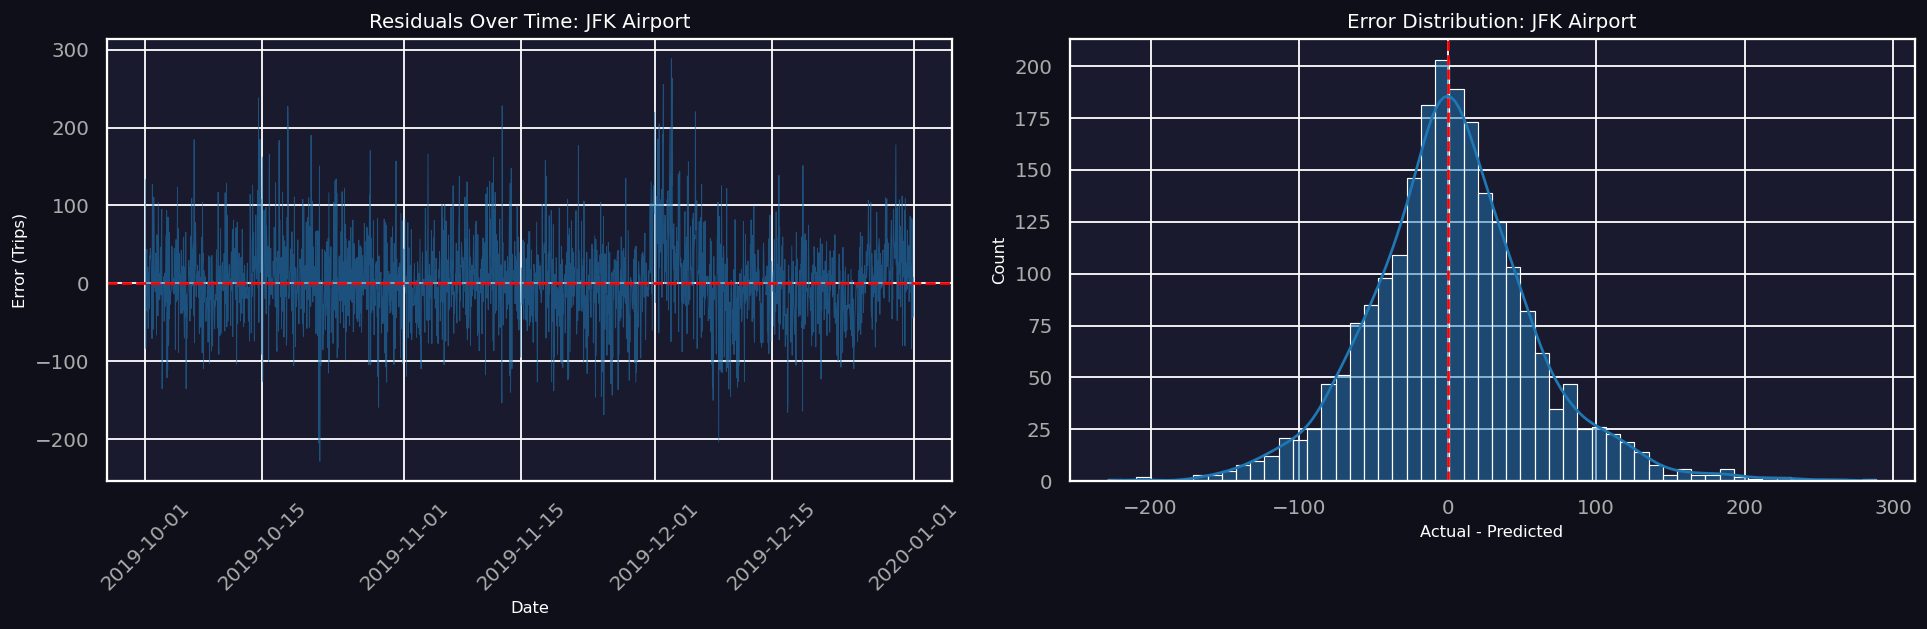

In [36]:
import matplotlib.pyplot as plt

def plot_zone_residuals(df_val, zone_name):
    # Filter for the specific zone
    zone_df = df_val[df_val['zone'] == zone_name].sort_values('pickup_hour_ts')

    # Calculate Residuals (Actual - Predicted)
    # Using the final inverse-transformed predictions
    zone_df['residual'] = zone_df['trip_count'] - zone_df['y_pred']

    plt.figure(figsize=(15, 5))

    # 1. Time Series Plot of Residuals
    plt.subplot(1, 2, 1)
    plt.plot(zone_df['pickup_hour_ts'], zone_df['residual'], color='tab:blue', alpha=0.6, linewidth=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Residuals Over Time: {zone_name}')
    plt.ylabel('Error (Trips)')
    plt.xlabel('Date')
    plt.xticks(rotation=45) # Apply rotation to x-axis tick labels here

    # 2. Distribution of Residuals
    plt.subplot(1, 2, 2)
    sns.histplot(zone_df['residual'], kde=True, color='tab:blue')
    plt.axvline(0, color='red', linestyle='--')
    plt.title(f'Error Distribution: {zone_name}')
    plt.xlabel('Actual - Predicted')

    plt.tight_layout()
    plt.show()

# Run for JFK and Upper East Side
plot_zone_residuals(val, "JFK Airport")
# plot_zone_residuals(val, "Upper East Side South")

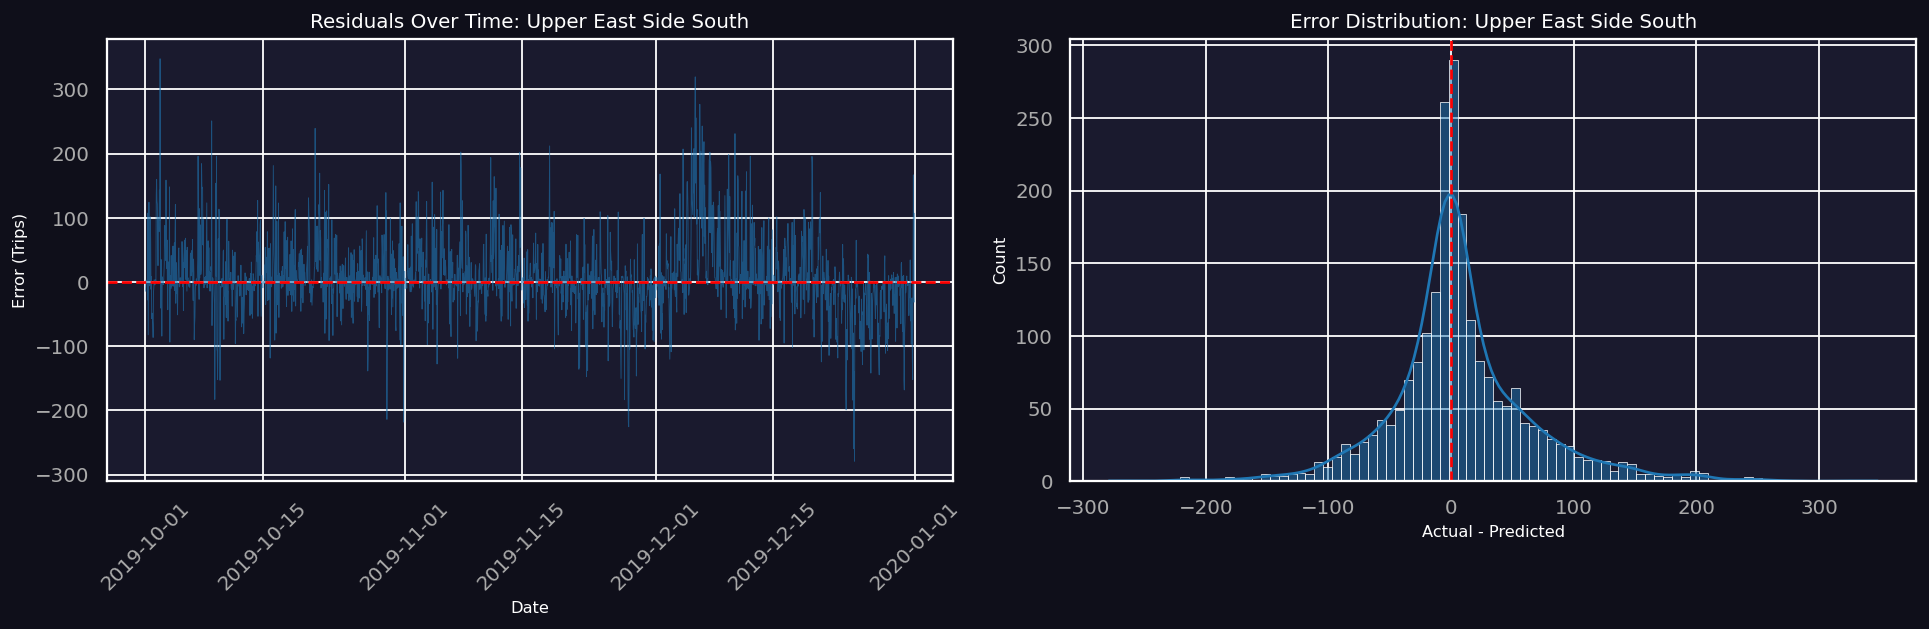

In [37]:
plot_zone_residuals(val, "Upper East Side South")

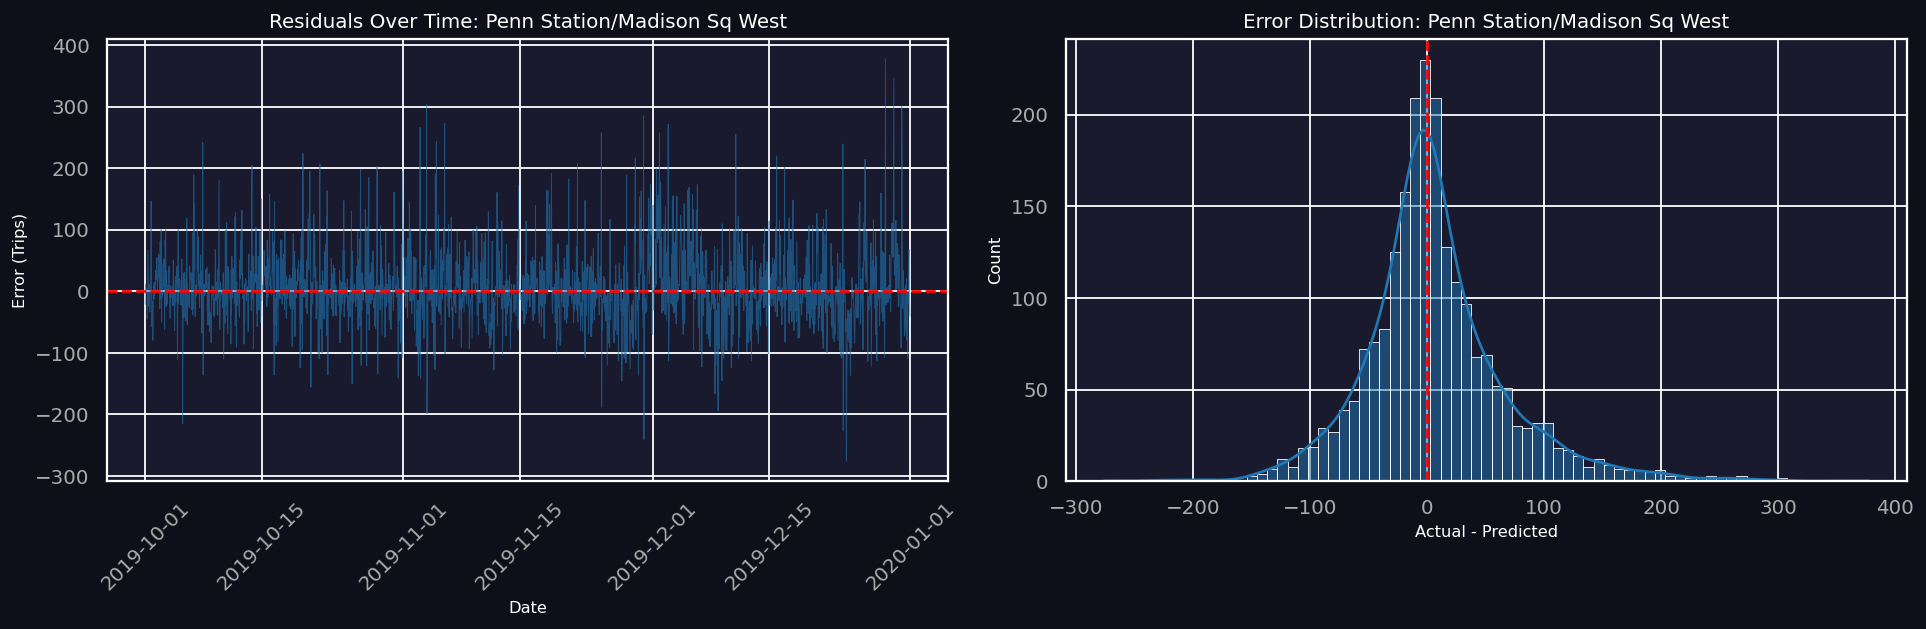

In [38]:
plot_zone_residuals(val, "Penn Station/Madison Sq West")

In [ ]:
val

,zone,pickup_hour_ts,trip_count,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,temperature_2m,precipitation,snowfall,...,lag_2h,lag_24h,lag_168h,roll_3h,roll_24h,roll_168h,month_of_year,y_pred,abs_error,squared_error
2216736,Hollis,2020-01-01 00:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.000000,0.041667,0.035714,1,0.000000,0.000000,0.000000
2216737,Bushwick North,2020-01-01 00:00:00,3.0,7.6600,29.1667,37.3333,1.6667,4.4,0.0,0.0,...,5.0,1.0,0.0,2.666667,0.583333,0.416667,1,1.922256,1.077744,1.161532
2216738,Seaport,2020-01-01 00:00:00,45.0,2.9842,12.1111,12.1556,1.6444,4.4,0.0,0.0,...,17.0,13.0,10.0,20.000000,14.750000,12.214286,1,10.682860,34.317140,1177.666121
2216739,Battery Park City,2020-01-01 00:00:00,55.0,3.8915,15.0273,15.5091,1.7818,4.4,0.0,0.0,...,40.0,5.0,3.0,42.666667,54.291667,49.005952,1,7.805316,47.194684,2227.338191
2216740,Douglaston,2020-01-01 00:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.000000,0.000000,0.023810,1,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2408683,East New York,2020-01-31 23:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.000000,0.125000,0.172619,1,0.000000,0.000000,0.000000
2408684,Longwood,2020-01-31 23:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.000000,0.166667,0.101190,1,0.000000,0.000000,0.000000
2408685,Bellerose,2020-01-31 23:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.000000,0.000000,0.041667,1,0.000000,0.000000,0.000000
2408686,Jackson Heights,2020-01-31 23:00:00,5.0,3.1650,12.6875,11.6250,1.0000,2.7,0.5,0.0,...,1.0,1.0,3.0,1.000000,2.500000,2.857143,1,2.638805,2.361195,5.575242


In [ ]:
# 1. Calculate average demand per zone
# zone_stats = train.groupby('zone')['trip_count'].mean()

In [ ]:
# display(zone_stats)

### Top 10 Zones by Average Trip Count

In [ ]:
# # Sort zone_stats to get top and bottom zones
# sorted_zone_stats = zone_stats.sort_values(ascending=False)

# # Top 10 zones
# top_10_zones = sorted_zone_stats.head(10)

# fig, ax = plt.subplots(figsize=(10, 6))
# sns.barplot(x=top_10_zones.values, y=top_10_zones.index, palette='viridis', ax=ax)
# ax.set_title('Top 10 Zones by Average Trip Count', color='white', fontweight='bold')
# ax.set_xlabel('Average Trip Count')
# ax.set_ylabel('Zone Name')
# plt.tight_layout()
# plt.show()

# # Optional: save the plot
# plot_path_top = OUT_DIR / "top_10_zones_trip_count.png"
# plt.savefig(plot_path_top, bbox_inches="tight", facecolor=fig.get_facecolor())
# print(f"  Plot saved to {plot_path_top}")

### Bottom 10 Zones by Average Trip Count

In [ ]:
# Bottom 10 zones
# bottom_10_zones = sorted_zone_stats.tail(10)

# fig, ax = plt.subplots(figsize=(10, 6))
# sns.barplot(x=bottom_10_zones.values, y=bottom_10_zones.index, palette='magma', ax=ax)
# ax.set_title('Bottom 10 Zones by Average Trip Count', color='white', fontweight='bold')
# ax.set_xlabel('Average Trip Count')
# ax.set_ylabel('Zone Name')
# plt.tight_layout()
# plt.show()

# # Optional: save the plot
# plot_path_bottom = OUT_DIR / "bottom_10_zones_trip_count.png"
# plt.savefig(plot_path_bottom, bbox_inches="tight", facecolor=fig.get_facecolor())
# print(f"  Plot saved to {plot_path_bottom}")

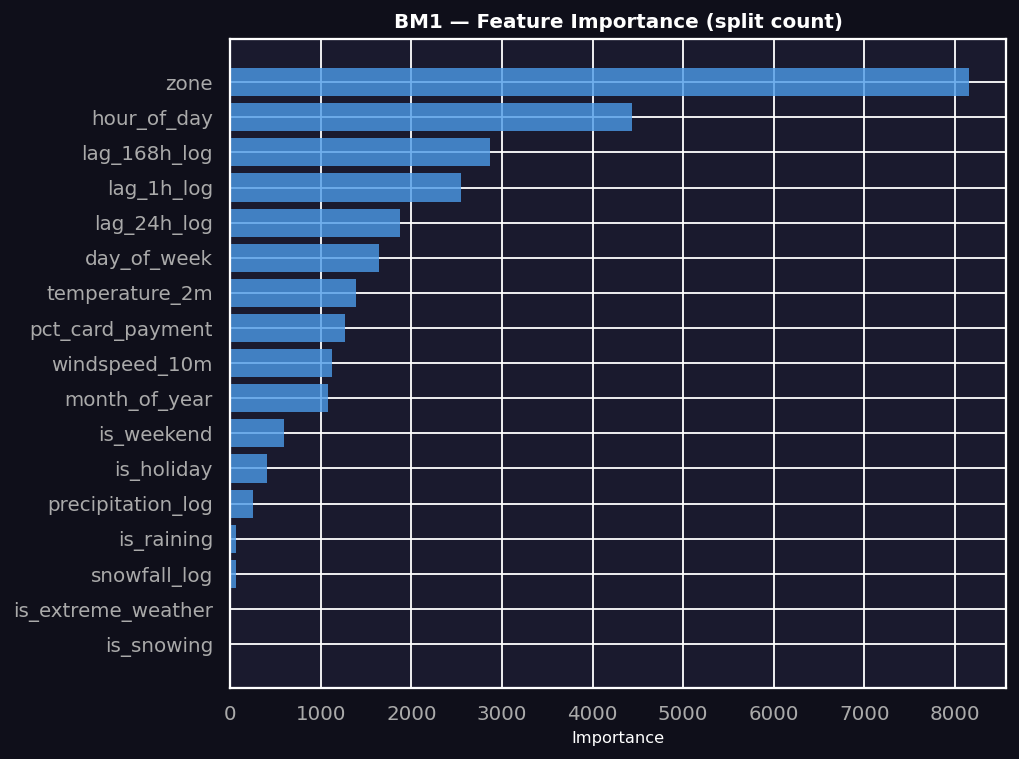

In [39]:
# ── Step 5: Feature importance ─────────────────────────────────────────────
# This tells you which features are actually driving predictions.
# Useful for your proposal and for deciding whether weather adds value.

fi = pd.DataFrame({
    "feature":    FEATURES,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi["feature"], fi["importance"],
        color="#4C9BE8", alpha=0.8, edgecolor="none")
ax.set_title("BM1 — Feature Importance (split count)",
             color="white", fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "BM1_feature_importance.png",
#             bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

In [40]:
# Save our model for future analysis
MODEL_DIR.mkdir(parents=True, exist_ok=True) # Ensure the directory exists
file = open(MODEL_DIR / "model.pkl", "wb")
pickle.dump(model, file)
file.close()

In [ ]:
# model = pd.read_pickle(MODEL_DIR / "model.pkl")

### Investigate into the rows which are driving high variance

### Top entries with highest squared error

In [ ]:
top_variance_entries = val.sort_values(by='squared_error', ascending=False).head(20)
display(top_variance_entries[['pickup_hour_ts', 'zone', 'trip_count', 'y_pred', 'abs_error', 'squared_error']])

,pickup_hour_ts,zone,trip_count,y_pred,abs_error,squared_error
2216909,2020-01-01 00:00:00,East Village,700.0,214.760145,485.239855,235457.717024
2217345,2020-01-01 02:00:00,Clinton East,668.0,253.105856,414.894144,172137.150663
2217472,2020-01-01 02:00:00,East Village,877.0,468.625281,408.374719,166769.911455
2389966,2020-01-28 23:00:00,Lincoln Square East,600.0,192.532182,407.467818,166030.022609
2217185,2020-01-01 01:00:00,Gramercy,572.0,177.523726,394.476274,155611.530809
2216858,2020-01-01 00:00:00,Upper East Side South,523.0,129.498391,393.501609,154843.516147
2217714,2020-01-01 03:00:00,East Village,860.0,486.812360,373.187640,139269.014804
2216987,2020-01-01 00:00:00,Lincoln Square East,479.0,106.850213,372.149787,138495.463618
2216805,2020-01-01 00:00:00,Midtown Center,465.0,100.771967,364.228033,132662.059659
2216891,2020-01-01 00:00:00,Murray Hill,449.0,100.229533,348.770467,121640.838514


These entries show the actual trip count versus the predicted trip count for the specific hour and zone where the model performed worst in terms of squared error. This can help identify patterns or specific events (like holidays, extreme weather, or unusual demand spikes) that the model struggled to predict accurately.

### Full details of Top 20 entries with highest squared error

In [ ]:
display(top_variance_entries[['pickup_hour_ts', 'zone', 'is_holiday', 'temperature_2m','trip_count', 'y_pred', 'abs_error', 'squared_error']])

,pickup_hour_ts,zone,is_holiday,temperature_2m,trip_count,y_pred,abs_error,squared_error
2216909,2020-01-01 00:00:00,East Village,True,4.4,700.0,214.760145,485.239855,235457.717024
2217345,2020-01-01 02:00:00,Clinton East,True,2.0,668.0,253.105856,414.894144,172137.150663
2217472,2020-01-01 02:00:00,East Village,True,2.0,877.0,468.625281,408.374719,166769.911455
2389966,2020-01-28 23:00:00,Lincoln Square East,False,1.9,600.0,192.532182,407.467818,166030.022609
2217185,2020-01-01 01:00:00,Gramercy,True,3.2,572.0,177.523726,394.476274,155611.530809
2216858,2020-01-01 00:00:00,Upper East Side South,True,4.4,523.0,129.498391,393.501609,154843.516147
2217714,2020-01-01 03:00:00,East Village,True,1.5,860.0,486.812360,373.187640,139269.014804
2216987,2020-01-01 00:00:00,Lincoln Square East,True,4.4,479.0,106.850213,372.149787,138495.463618
2216805,2020-01-01 00:00:00,Midtown Center,True,4.4,465.0,100.771967,364.228033,132662.059659
2216891,2020-01-01 00:00:00,Murray Hill,True,4.4,449.0,100.229533,348.770467,121640.838514


Holiday Impact is Significant: A striking observation is that many of these high-error entries occur on January 1, 2020. The is_holiday column is True for these dates. New Year's Day is a major holiday with unique travel patterns (e.g., late-night demand from celebrations, followed by reduced daytime activity for some, and specific travel to/from certain venues). Our model, trained primarily on 2019 data (which likely didn't capture the New Year's transition perfectly into a new year's validation set), seems to be consistently underpredicting demand for these high-activity hours during the holiday.

Weather Impact (Less Direct for Top Errors): For the majority of these top error entries (especially on January 1st), the weather conditions (precipitation, snowfall, is_snowing, is_raining, is_extreme_weather) are 0.0 or False. This suggests that for these particular instances of large errors, extreme weather was not a primary contributing factor. The errors appear to be more related to the unusual demand patterns of a major holiday rather than adverse weather conditions. While weather is generally an important feature, it doesn't seem to be the direct cause of these most extreme prediction failures.

High-Demand Urban Zones: The zones experiencing these large errors are predominantly high-traffic areas in Manhattan, such as 'East Village', 'Clinton East', 'Lincoln Square East', 'Gramercy', 'Midtown Center', and 'Penn Station/Madison Sq West'. These zones typically have high taxi demand, and any deviation from learned patterns can lead to large absolute errors.

In summary, the model seems to struggle significantly with predicting demand during major holidays, particularly New Year's Day, in busy Manhattan zones. It consistently underpredicts the actual trip counts during these periods, indicating a need for more robust holiday feature engineering or handling of unique holiday demand spikes.

### What if we log transform our predictor?

In [ ]:

# TRAIN_END = '2019-07-31 23:00:00'
# VAL_START = '2019-08-01 00:00:00'

# train = df_model[df_model['pickup_hour_ts'] <= TRAIN_END]
# val   = df_model[df_model['pickup_hour_ts'] >= VAL_START]

# X_train, y_train = train[FEATURES], train[TARGET]
# X_val,   y_val   = val[FEATURES],   val[TARGET]

# # Transform the Target
# y_train_log = np.log1p(y_train)
# y_val_log   = np.log1p(y_val)

# # By default, LightGBM treats all imputs as continuous so we have to explicitly
# # convert zone into a category type.
# X_train['zone'] = X_train['zone'].astype('category')
# X_val['zone'] = X_val['zone'].astype('category')

# # Explicitly convert boolean features to bool type after filling NaNs
# boolean_features = ['is_weekend', 'is_holiday', 'is_snowing', 'is_raining', 'is_extreme_weather']

# for feature in boolean_features:
#     X_train[feature] = X_train[feature].fillna(False).astype(bool)
#     X_val[feature] = X_val[feature].fillna(False).astype(bool)

# print(f"Train: {len(X_train):,} rows  ({train['pickup_hour_ts'].min().date()} → {train['pickup_hour_ts'].max().date()})")
# print(f"Val:   {len(X_val):,}   rows  ({val['pickup_hour_ts'].min().date()} → {val['pickup_hour_ts'].max().date()})")

# params = {
#     'objective':          'regression',
#     'metric':             'rmse',
#     'n_estimators':       2000,
#     'learning_rate':      0.05,
#     'num_leaves':         63,
#     'min_child_samples':  20,
#     'subsample':          0.8,
#     'colsample_bytree':   0.8,
#     'random_state':       42,
#     'verbose':            -1,
# }

# model_log = lgb.LGBMRegressor(**params)
# model_log.fit(
#     X_train, y_train,
#     eval_set=[(X_val, y_val)],
#     callbacks=[
#         lgb.early_stopping(stopping_rounds=50),
#         lgb.log_evaluation(period=100),
#     ]
# )

# # Inverse Transform for Evaluation
# # Use np.expm1 to get back to original trip counts: exp(x) - 1
# y_pred_log = model_log.predict(X_val)
# y_pred_final = np.expm1(np.clip(y_pred_log, 0, None))
# mae    = mean_absolute_error(y_val, y_pred_final)
# rmse   = np.sqrt(mean_squared_error(y_val, y_pred_final))
# nmae   = mae / y_val.mean()

# print(f"── Log-Transformed Results ──")
# print(f"  MAE:            {mae:.3f} trips")
# print(f"  RMSE:           {rmse:.3f} trips")
# print(f"  Normalised MAE: {nmae:.3%}")
# print(f"  Mean demand:    {y_val.mean():.2f} trips/hr")
# print(f"  Best iteration: {model.best_iteration_}")

# print(" Section 7 complete — baseline model trained")

/tmp/ipykernel_674/4218891466.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['zone'] = X_train['zone'].astype('category')
/tmp/ipykernel_674/4218891466.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val['zone'] = X_val['zone'].astype('category')
/tmp/ipykernel_674/4218891466.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, s

Train: 1,269,360 rows  (2019-01-08 → 2019-07-31)
Val:   945,054   rows  (2019-08-01 → 2019-12-31)
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 11.2901
[200]	valid_0's rmse: 10.0704
[300]	valid_0's rmse: 9.69234
[400]	valid_0's rmse: 9.38629
[500]	valid_0's rmse: 9.03603
[600]	valid_0's rmse: 8.89841
[700]	valid_0's rmse: 8.76094
[800]	valid_0's rmse: 8.63335
[900]	valid_0's rmse: 8.54235
[1000]	valid_0's rmse: 8.49416
[1100]	valid_0's rmse: 8.42696
[1200]	valid_0's rmse: 8.32496
[1300]	valid_0's rmse: 8.26182
[1400]	valid_0's rmse: 8.23016
[1500]	valid_0's rmse: 8.1775
[1600]	valid_0's rmse: 8.13233
[1700]	valid_0's rmse: 8.06017
[1800]	valid_0's rmse: 8.03564
Early stopping, best iteration is:
[1846]	valid_0's rmse: 8.02699


/tmp/ipykernel_674/4218891466.py:55: RuntimeWarning: overflow encountered in expm1
  y_pred_final = np.expm1(np.clip(y_pred_log, 0, None))


ValueError: Input contains infinity or a value too large for dtype('float64').

# Section 8: Drfit Detection

In [ ]:
# Load optimal model

with open(MODEL_DIR / "model.pkl", "rb") as f:
    model = pickle.load(f)
print(f"  Model loaded — best iteration: {model.best_iteration_}")

  Model loaded — best iteration: 1055


In [ ]:
# Load revised feature set
# Removed redundant features deemed not important
# and removed average values e.g average passenger count to avoid leakage risk

# ── Feature list — must exactly match what the model was trained on ───────────
# These are the original 20 features from Section 7.
# DO NOT change this list unless you retrain the model from scratch.
FEATURES = [
    'hour_of_day', 'day_of_week', 'is_weekend', 'month_of_year',
    'temperature_2m', 'precipitation', 'snowfall', 'windspeed_10m',
    'is_snowing', 'is_raining', 'is_extreme_weather',
    'is_holiday', 'zone',
    'lag_1h', 'lag_24h', 'lag_168h'
]

# Sanity check — catch mismatches before the loop runs
assert len(FEATURES) == model.n_features_in_, (
    f"Feature mismatch: FEATURES has {len(FEATURES)} but model expects "
    f"{model.n_features_in_}. Check the list above against Section 7."
)
print(f"  Feature count check passed: {len(FEATURES)} features")

TARGET = 'trip_count'
BOOLEAN_FEATURES = ['is_weekend', 'is_holiday', 'is_snowing',
                    'is_raining', 'is_extreme_weather']

TEST_MONTHS_2020 = [
    '2020-01', '2020-02', '2020-03', '2020-04',
    '2020-05', '2020-06',
]
BASELINE_MONTHS = [
    '2019-01', '2019-02', '2019-03', '2019-04',
    '2019-05', '2019-06', '2019-07', '2019-08',
    '2019-09', '2019-10', '2019-11', '2019-12',
]

print(f"  Section 8-A ready")

  Feature count check passed: 16 features
  Section 8-A ready


In [ ]:
# Prep Features
def prepare_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if 'month_of_year' not in df.columns:
        df['month_of_year'] = df['pickup_hour_ts'].dt.month
    df['zone'] = df['zone'].astype('category')
    for col in BOOLEAN_FEATURES:
        if col in df.columns:
            # Use recommended pattern to avoid FutureWarning
            df[col] = df[col].fillna(False).infer_objects(copy=False).astype(bool)
    return df

### Implementation of Population Stability Index Calculation

Need to understand the code below a bit better:
https://medium.com/model-monitoring-psi/population-stability-index-psi-ab133b0a5d42

In [ ]:
def compute_psi(reference: pd.Series,
                test: pd.Series,
                n_bins: int = 10) -> float:
    """
    Population Stability Index between a reference and test distribution.

    PSI < 0.10  → no significant shift
    PSI 0.10–0.25 → moderate shift, worth monitoring
    PSI > 0.25  → significant shift — distribution has moved

    Works for both continuous and boolean/categorical series.
    Categorical series are binned by unique value rather than quantile.
    Returns NaN if either series is empty or all-constant.
    """

    # Drop missing values from reference and test datasets
    reference = reference.dropna()
    test = test.dropna()

    if len(reference) == 0 or len(test) == 0:
        return np.nan

    # Boolean / low-cardinality categorical → value-based bins
    n_unique = reference.nunique()
    if n_unique <= 5 or reference.dtype == bool:
        categories = sorted(reference.unique().tolist())
        ref_counts = reference.value_counts(normalize=True).reindex(categories, fill_value=1e-6)
        tst_counts = test.value_counts(normalize=True).reindex(categories, fill_value=1e-6)
        ref_pct = ref_counts.values
        tst_pct = tst_counts.values
    else:
        # Continuous → quantile-based binning on the reference
        breakpoints = np.unique(
            np.nanpercentile(reference, np.linspace(0, 100, n_bins + 1))
        )
        if len(breakpoints) < 2:
            return np.nan

        ref_counts, _ = np.histogram(reference, bins=breakpoints)
        tst_counts, _ = np.histogram(test,      bins=breakpoints)

        # Clip to avoid log(0); normalise to proportions
        ref_pct = np.clip(ref_counts / len(reference), 1e-6, None)
        tst_pct = np.clip(tst_counts / len(test),      1e-6, None)

    psi = np.sum((tst_pct - ref_pct) * np.log(tst_pct / ref_pct))
    return float(psi)

### Predict each 2020 month, compute daily metrics and PSI

In [ ]:
# ── Build 2019 baseline once (PSI reference) ──────────────────────────────────
print("Loading 2019 baseline for PSI reference …")
df_baseline_raw = load_gold(BASELINE_MONTHS)
df_baseline = build_lag_features(df_baseline_raw)
df_baseline = df_baseline.dropna(subset=['lag_168h'])
df_baseline = prepare_features(df_baseline)
display(df_baseline)

Loading 2019 baseline for PSI reference …
  Loaded 1,064,915 rows across 12 months
  Found 4332 multiple rows for zone and pickup_hour_ts group. Displaying first 10 duplicates:


,pickup_hour_ts,file_month,PULocationID,borough,zone,trip_count,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,...,is_weekend,is_holiday,temperature_2m,precipitation,snowfall,windspeed_10m,weathercode,is_snowing,is_raining,is_extreme_weather
1959,2019-01-31 23:00:00,2019-01,4,Manhattan,Alphabet City,40,2.4082,10.5875,11.0500,1.6000,...,False,False,-10.2,0.0,0.0,12.7,0,False,False,False
1960,2019-01-31 23:00:00,2019-02,4,Manhattan,Alphabet City,1,4.6600,15.5000,16.0000,1.0000,...,False,False,-10.2,0.0,0.0,12.7,0,False,False,False
2631,2019-02-28 23:00:00,2019-02,4,Manhattan,Alphabet City,43,2.6944,11.7209,13.0233,1.3721,...,False,False,-3.5,0.0,0.0,8.2,3,False,False,False
2632,2019-02-28 23:00:00,2019-03,4,Manhattan,Alphabet City,1,2.9300,14.0000,18.0000,1.0000,...,False,False,-3.5,0.0,0.0,8.2,3,False,False,False
4092,2019-05-01 00:00:00,2019-04,4,Manhattan,Alphabet City,1,0.5200,4.0000,2.0000,1.0000,...,False,False,9.8,0.0,0.0,6.6,1,False,False,False
4093,2019-05-01 00:00:00,2019-05,4,Manhattan,Alphabet City,7,3.1686,12.0714,11.7143,1.2857,...,False,False,9.8,0.0,0.0,6.6,1,False,False,False
4834,2019-05-31 23:00:00,2019-05,4,Manhattan,Alphabet City,36,2.7211,12.5000,14.9444,1.6389,...,False,False,18.3,0.0,0.0,7.0,0,False,False,False
4835,2019-05-31 23:00:00,2019-06,4,Manhattan,Alphabet City,2,2.3750,10.2500,10.0000,1.0000,...,False,False,18.3,0.0,0.0,7.0,0,False,False,False
6289,2019-07-31 23:00:00,2019-07,4,Manhattan,Alphabet City,17,2.2900,9.8824,10.1765,1.5294,...,False,False,23.6,0.0,0.0,3.4,3,False,False,False
6290,2019-07-31 23:00:00,2019-08,4,Manhattan,Alphabet City,3,7.0233,22.6667,20.0000,2.6667,...,False,False,23.6,0.0,0.0,3.4,3,False,False,False


  Aggregating 4332 duplicate rows...
  Aggregated to 1062748 unique rows.
  Lag features built — 2,260,080 rows (includes spine fill)


/tmp/ipykernel_23083/924962276.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False).astype(bool)
/tmp/ipykernel_23083/924962276.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False).astype(bool)
/tmp/ipykernel_23083/924962276.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


,zone,pickup_hour_ts,trip_count,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,temperature_2m,precipitation,snowfall,...,hour_of_day,day_of_week,lag_1h,lag_2h,lag_24h,lag_168h,roll_3h,roll_24h,roll_168h,month_of_year
168,Allerton/Pelham Gardens,2019-01-08 00:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,0.333333,0.220238,1
169,Allerton/Pelham Gardens,2019-01-08 01:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,0.333333,0.220238,1
170,Allerton/Pelham Gardens,2019-01-08 02:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,0.333333,0.220238,1
171,Allerton/Pelham Gardens,2019-01-08 03:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,0.333333,0.220238,1
172,Allerton/Pelham Gardens,2019-01-08 04:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,0.333333,0.220238,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260075,Yorkville West,2019-12-31 19:00:00,278.0,2.1455,9.3993,9.5504,1.6007,4.4,0.0,0.0,...,19.0,2.0,284.0,211.0,161.0,181.0,227.333333,133.916667,115.130952,12
2260076,Yorkville West,2019-12-31 20:00:00,422.0,2.2170,9.6434,10.1303,1.7915,4.3,0.0,0.0,...,20.0,2.0,278.0,284.0,137.0,166.0,257.666667,138.791667,115.708333,12
2260077,Yorkville West,2019-12-31 21:00:00,332.0,2.2652,9.8584,10.4006,1.8916,4.9,0.1,0.0,...,21.0,2.0,422.0,278.0,121.0,160.0,328.000000,150.666667,117.232143,12
2260078,Yorkville West,2019-12-31 22:00:00,235.0,2.2575,9.3872,8.9404,1.8000,4.7,0.1,0.0,...,22.0,2.0,332.0,422.0,108.0,141.0,344.000000,159.458333,118.255952,12


In [ ]:
# Only pick the features we're interested in
df_baseline_subset = df_baseline[FEATURES + [TARGET]]
df_baseline_subset.head()

,hour_of_day,day_of_week,is_weekend,month_of_year,temperature_2m,precipitation,snowfall,windspeed_10m,is_snowing,is_raining,is_extreme_weather,is_holiday,zone,lag_1h,lag_24h,lag_168h,trip_count
168,NaN,NaN,False,1,NaN,NaN,NaN,NaN,False,False,False,False,Allerton/Pelham Gardens,0.0,0.0,0.0,0.0
169,NaN,NaN,False,1,NaN,NaN,NaN,NaN,False,False,False,False,Allerton/Pelham Gardens,0.0,0.0,0.0,0.0
170,NaN,NaN,False,1,NaN,NaN,NaN,NaN,False,False,False,False,Allerton/Pelham Gardens,0.0,0.0,0.0,0.0
171,NaN,NaN,False,1,NaN,NaN,NaN,NaN,False,False,False,False,Allerton/Pelham Gardens,0.0,0.0,0.0,0.0
172,NaN,NaN,False,1,NaN,NaN,NaN,NaN,False,False,False,False,Allerton/Pelham Gardens,0.0,0.0,0.0,0.0


In [ ]:
# ── Build 2019 baseline once ──────────────────────────────────────────────────
print("Loading 2019 baseline for PSI reference …")
df_baseline_raw = load_gold(BASELINE_MONTHS)
df_baseline = build_lag_features(df_baseline_raw)
df_baseline = df_baseline.dropna(subset=['lag_168h'])
df_baseline = prepare_features(df_baseline)

PSI_FEATURES      = [f for f in FEATURES if f not in ('zone',) + tuple(BOOLEAN_FEATURES)]
BOOL_PSI_FEATURES = BOOLEAN_FEATURES
ALL_PSI_FEATURES  = PSI_FEATURES + BOOL_PSI_FEATURES

print(f"  Baseline rows: {len(df_baseline):,}")

# ── Storage ───────────────────────────────────────────────────────────────────
monthly_metrics = []
daily_metrics   = []
psi_records     = []

# ── Main loop ─────────────────────────────────────────────────────────────────
for i, month in enumerate(TEST_MONTHS_2020):
    print(f"\n{'─'*52}")
    print(f"  {month}")
    print(f"{'─'*52}")

    months_to_load = TEST_MONTHS_2020[:i + 1]

    try:
        df_raw  = load_gold(months_to_load)
        df_feat = build_lag_features(df_raw)
        df_feat = df_feat.dropna(subset=['lag_168h'])
        df_feat = prepare_features(df_feat)

        # Filter to current month only
        mask     = df_feat['pickup_hour_ts'].dt.to_period('M').astype(str) == month
        df_month = df_feat[mask].copy()

        if df_month.empty:
            print(f"  No data for {month} — skipping")
            continue

        # ── Feature guard: catch mismatches before predict ────────────────────
        missing = [f for f in FEATURES if f not in df_month.columns]
        if missing:
            raise ValueError(
                f"Features missing from df_month for {month}: {missing}\n"
                f"  Available columns: {list(df_month.columns)}\n"
                f"  This usually means build_lag_features() didn't produce these "
                f"columns. Check that rolling features are being built."
            )

        X      = df_month[FEATURES]
        y_true = df_month[TARGET]

        # ── Predict ───────────────────────────────────────────────────────────
        y_pred = np.clip(model.predict(X), 0, None)
        df_month = df_month.copy()
        df_month['y_pred']    = y_pred
        df_month['abs_error'] = np.abs(y_true - y_pred)

        # ── Monthly metrics ───────────────────────────────────────────────────
        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        wape = df_month['abs_error'].sum() / y_true.sum()

        monthly_metrics.append({
            'month':       month,
            'month_dt':    pd.to_datetime(month + '-01'),
            'mae':         mae,
            'rmse':        rmse,
            'wape':        wape,
            'mean_actual': y_true.mean(),
            'n_rows':      len(df_month),
        })
        print(f"  MAE={mae:.2f}  RMSE={rmse:.2f}  WAPE={wape:.2%}  "
              f"mean_actual={y_true.mean():.1f}")

        # ── Daily metrics ─────────────────────────────────────────────────────
        df_month['date'] = df_month['pickup_hour_ts'].dt.date
        for date, grp in df_month.groupby('date'):
            daily_metrics.append({
                'date':  pd.Timestamp(date),
                'month': month,
                'mae':   grp['abs_error'].mean(),
                'wape':  grp['abs_error'].sum() / grp[TARGET].sum(),
            })

        # ── PSI per feature ───────────────────────────────────────────────────
        for feat in ALL_PSI_FEATURES:
            if feat not in df_baseline.columns or feat not in df_month.columns:
                continue
            psi_val = compute_psi(df_baseline[feat], df_month[feat])
            psi_records.append({
                'month':    month,
                'month_dt': pd.to_datetime(month + '-01'),
                'feature':  feat,
                'psi':      psi_val,
            })

    except Exception as e:
        print(f"  ERROR for {month}: {e}")
        # Still append a NaN row so plots don't have gaps without explanation
        monthly_metrics.append({
            'month': month, 'month_dt': pd.to_datetime(month + '-01'),
            'mae': np.nan, 'rmse': np.nan, 'wape': np.nan,
            'mean_actual': np.nan, 'n_rows': 0,
        })
    finally:
        # Free memory regardless of success/failure
        try:
            del df_raw, df_feat
        except NameError:
            pass
        gc.collect()

# ── Assemble ──────────────────────────────────────────────────────────────────
df_monthly = pd.DataFrame(monthly_metrics).sort_values('month_dt').reset_index(drop=True)
df_daily   = pd.DataFrame(daily_metrics).sort_values('date').reset_index(drop=True)
df_psi     = pd.DataFrame(psi_records)

print(f"\n{'═'*52}")
print(f"  Monthly metrics : {len(df_monthly)} rows")
print(f"  Daily metrics   : {len(df_daily)} rows")
print(f"  PSI records     : {len(df_psi)} rows")
print(f"{'═'*52}")
display(df_monthly[['month', 'mae', 'rmse', 'wape', 'mean_actual', 'n_rows']])


Loading 2019 baseline for PSI reference …
  Loaded 1,064,915 rows across 12 months
  Found 4332 multiple rows for zone and pickup_hour_ts group. Displaying first 10 duplicates:


,pickup_hour_ts,file_month,PULocationID,borough,zone,trip_count,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,...,is_weekend,is_holiday,temperature_2m,precipitation,snowfall,windspeed_10m,weathercode,is_snowing,is_raining,is_extreme_weather
1959,2019-01-31 23:00:00,2019-01,4,Manhattan,Alphabet City,40,2.4082,10.5875,11.0500,1.6000,...,False,False,-10.2,0.0,0.0,12.7,0,False,False,False
1960,2019-01-31 23:00:00,2019-02,4,Manhattan,Alphabet City,1,4.6600,15.5000,16.0000,1.0000,...,False,False,-10.2,0.0,0.0,12.7,0,False,False,False
2631,2019-02-28 23:00:00,2019-02,4,Manhattan,Alphabet City,43,2.6944,11.7209,13.0233,1.3721,...,False,False,-3.5,0.0,0.0,8.2,3,False,False,False
2632,2019-02-28 23:00:00,2019-03,4,Manhattan,Alphabet City,1,2.9300,14.0000,18.0000,1.0000,...,False,False,-3.5,0.0,0.0,8.2,3,False,False,False
4092,2019-05-01 00:00:00,2019-04,4,Manhattan,Alphabet City,1,0.5200,4.0000,2.0000,1.0000,...,False,False,9.8,0.0,0.0,6.6,1,False,False,False
4093,2019-05-01 00:00:00,2019-05,4,Manhattan,Alphabet City,7,3.1686,12.0714,11.7143,1.2857,...,False,False,9.8,0.0,0.0,6.6,1,False,False,False
4834,2019-05-31 23:00:00,2019-05,4,Manhattan,Alphabet City,36,2.7211,12.5000,14.9444,1.6389,...,False,False,18.3,0.0,0.0,7.0,0,False,False,False
4835,2019-05-31 23:00:00,2019-06,4,Manhattan,Alphabet City,2,2.3750,10.2500,10.0000,1.0000,...,False,False,18.3,0.0,0.0,7.0,0,False,False,False
6289,2019-07-31 23:00:00,2019-07,4,Manhattan,Alphabet City,17,2.2900,9.8824,10.1765,1.5294,...,False,False,23.6,0.0,0.0,3.4,3,False,False,False
6290,2019-07-31 23:00:00,2019-08,4,Manhattan,Alphabet City,3,7.0233,22.6667,20.0000,2.6667,...,False,False,23.6,0.0,0.0,3.4,3,False,False,False


  Aggregating 4332 duplicate rows...
  Aggregated to 1062748 unique rows.
  Lag features built — 2,260,080 rows (includes spine fill)


/tmp/ipykernel_23083/1626308719.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False).infer_objects(copy=False).astype(bool)
/tmp/ipykernel_23083/1626308719.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False).infer_objects(copy=False).astype(bool)
/tmp/ipykernel_23083/1626308719.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set

  Baseline rows: 2,216,736

────────────────────────────────────────────────────
  2020-01
────────────────────────────────────────────────────
  Loaded 78,135 rows across 1 months
  Found 4 multiple rows for zone and pickup_hour_ts group. Displaying first 10 duplicates:


...

,pickup_hour_ts,file_month,PULocationID,borough,zone,trip_count,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,...,is_weekend,is_holiday,temperature_2m,precipitation,snowfall,windspeed_10m,weathercode,is_snowing,is_raining,is_extreme_weather
1565,2020-02-29 22:00:00,2020-02,4,Manhattan,Alphabet City,46,2.8176,12.7717,15.1522,1.3261,...,True,False,-3.2,0.0,0.0,14.5,0,False,False,False
1566,2020-02-29 22:00:00,2020-03,4,Manhattan,Alphabet City,1,2.1500,10.0000,11.0000,1.0000,...,True,False,-3.2,0.0,0.0,14.5,0,False,False,False
1567,2020-02-29 23:00:00,2020-02,4,Manhattan,Alphabet City,72,2.3008,10.8264,12.5278,1.7083,...,True,False,-3.5,0.0,0.0,16.1,0,False,False,False
1568,2020-02-29 23:00:00,2020-03,4,Manhattan,Alphabet City,1,1.8700,9.5000,12.0000,1.0000,...,True,False,-3.5,0.0,0.0,16.1,0,False,False,False
3566,2020-01-31 16:00:00,2020-01,7,Queens,Astoria,9,1.4567,7.7778,10.5556,1.3333,...,False,False,5.6,0.0,0.0,11.3,3,False,False,False
3567,2020-01-31 16:00:00,2020-02,7,Queens,Astoria,1,1.0400,6.0000,6.0000,6.0000,...,False,False,5.6,0.0,0.0,11.3,3,False,False,False
10433,2020-02-29 22:00:00,2020-02,13,Manhattan,Battery Park City,44,3.0609,12.2386,11.9091,1.8182,...,True,False,-3.2,0.0,0.0,14.5,0,False,False,False
10434,2020-02-29 22:00:00,2020-03,13,Manhattan,Battery Park City,1,4.4400,14.5000,11.0000,1.0000,...,True,False,-3.2,0.0,0.0,14.5,0,False,False,False
10612,2020-03-08 10:00:00,2020-03,13,Manhattan,Battery Park City,45,3.2036,12.5556,11.0889,1.6667,...,True,False,4.7,0.0,0.0,9.7,2,False,False,False
10613,2020-03-08 10:00:00,2020-04,13,Manhattan,Battery Park City,1,1.6400,7.5000,8.0000,2.0000,...,True,False,4.7,0.0,0.0,9.7,2,False,False,False


  Aggregating 967 duplicate rows...
  Aggregated to 334657 unique rows.
  Lag features built — 1,892,688 rows (includes spine fill)


/tmp/ipykernel_23083/1626308719.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False).infer_objects(copy=False).astype(bool)
/tmp/ipykernel_23083/1626308719.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False).infer_objects(copy=False).astype(bool)
/tmp/ipykernel_23083/1626308719.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set

  MAE=1.12  RMSE=4.01  WAPE=45.28%  mean_actual=2.5

════════════════════════════════════════════════════
  Monthly metrics : 6 rows
  Daily metrics   : 175 rows
  PSI records     : 90 rows
════════════════════════════════════════════════════


,month,mae,rmse,wape,mean_actual,n_rows
0,2020-01,3.867819,12.634103,0.114242,33.856221,144576
1,2020-02,3.824368,12.639994,0.113431,33.715258,177480
2,2020-03,3.936529,13.054372,0.264588,14.877951,190464
3,2020-04,1.116155,3.943634,1.024989,1.088943,185760
4,2020-05,0.990976,3.489493,0.716578,1.382929,191952
5,2020-06,1.123524,4.008820,0.452752,2.481541,185760


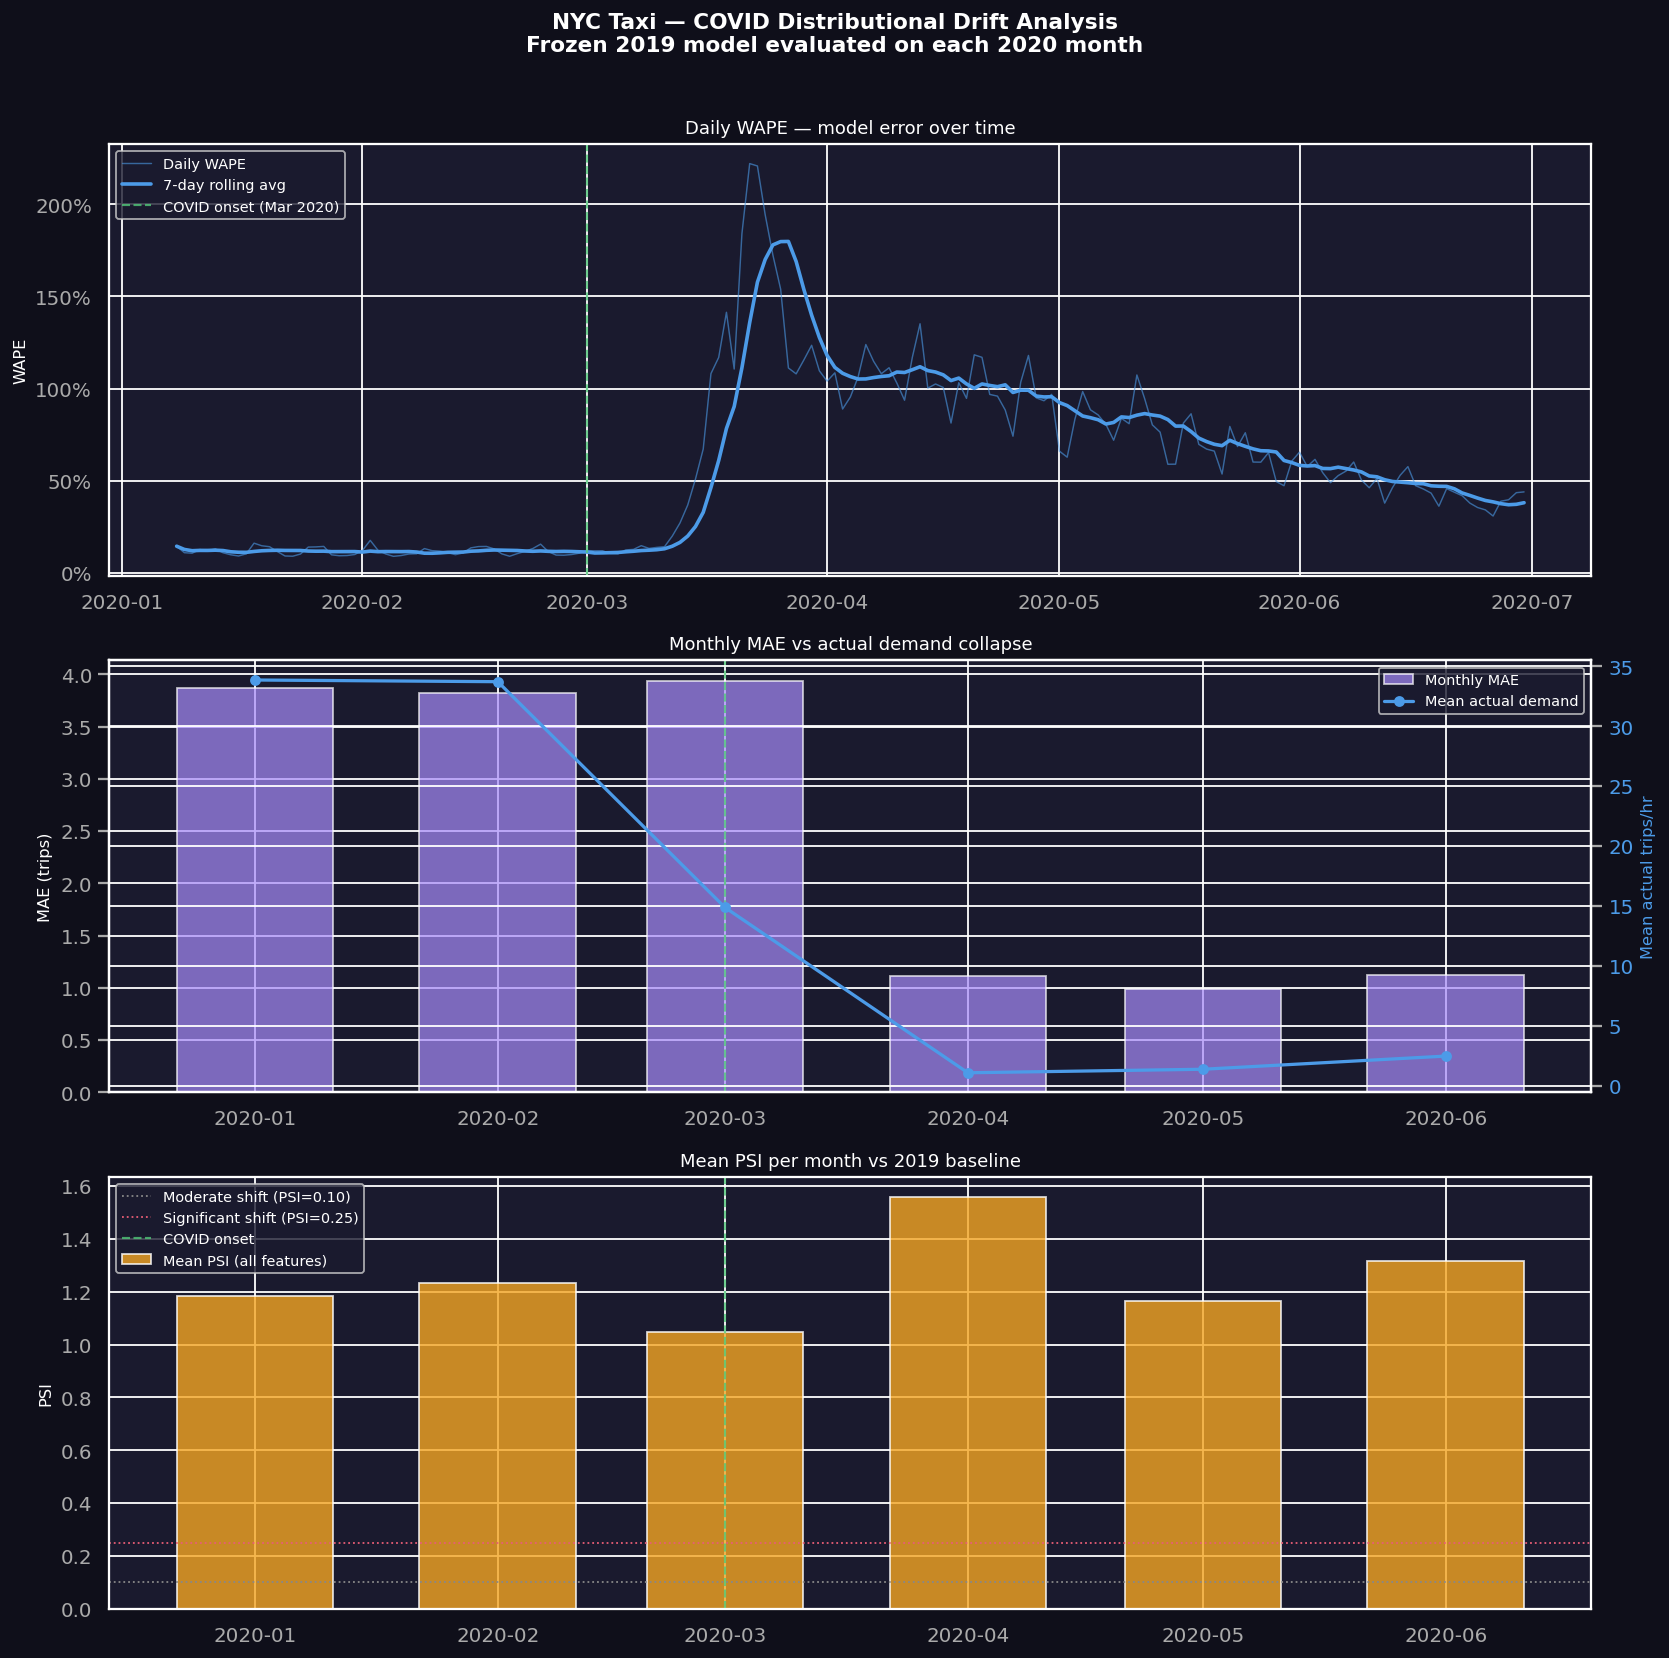

  Plot saved: /content/drive/MyDrive/ODATA57078/eda_outputs/covid_drift_analysis.png


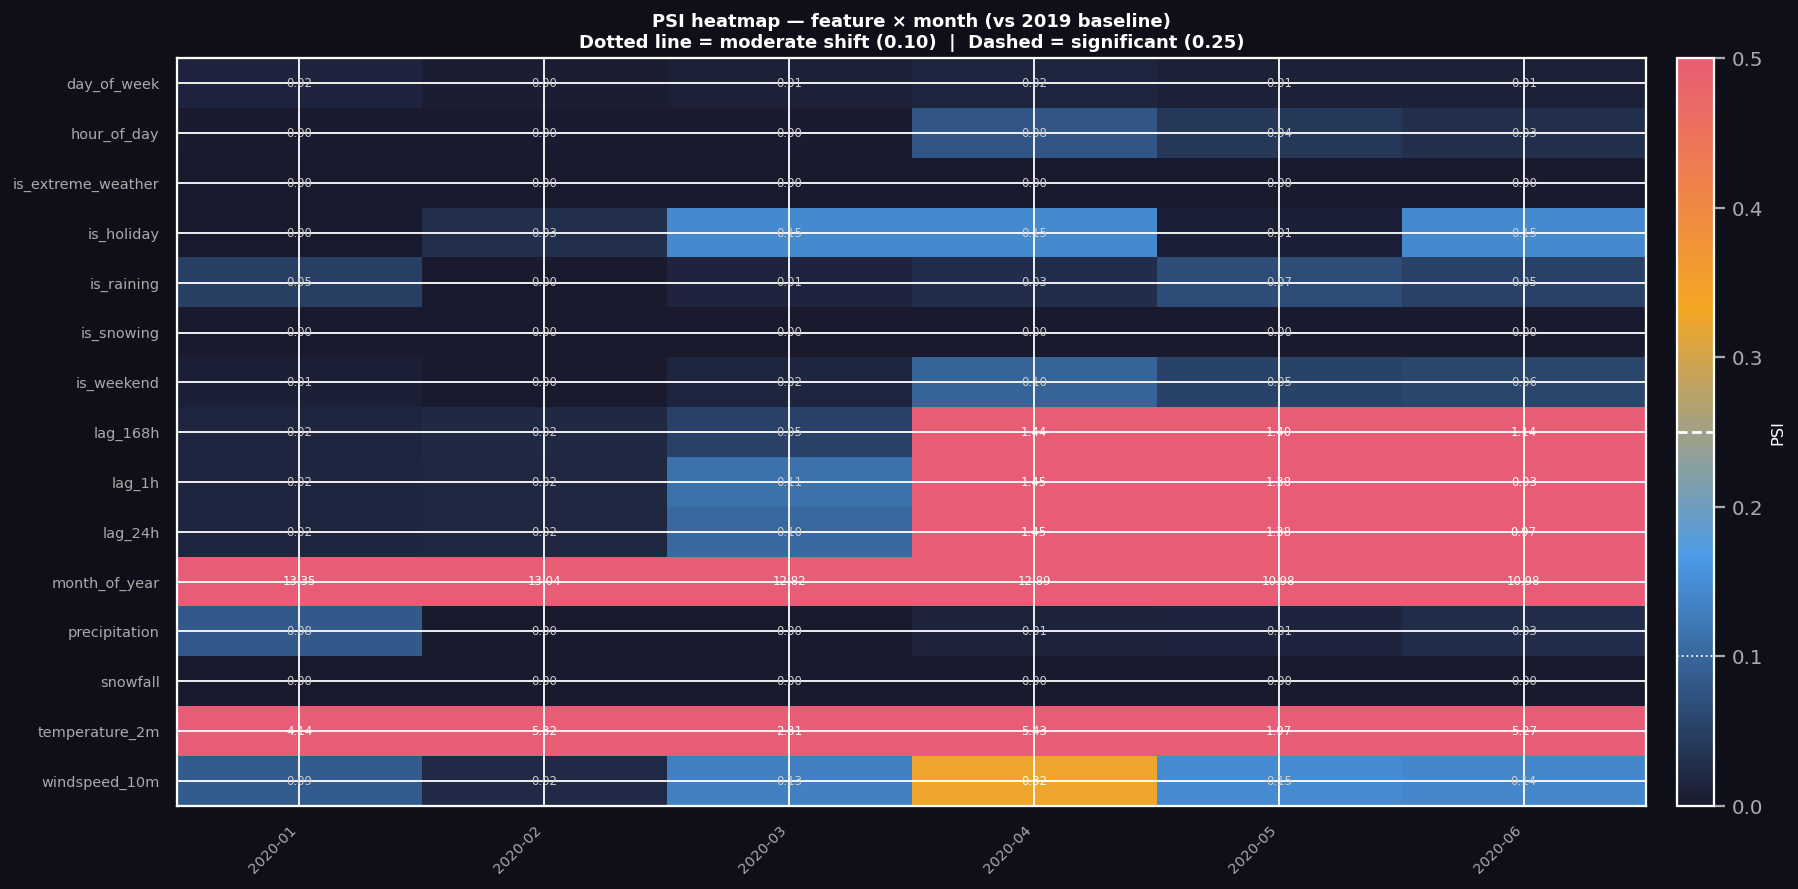

  Heatmap saved: /content/drive/MyDrive/ODATA57078/eda_outputs/psi_heatmap.png

── Monthly Summary ─────────────────────────────────────────────────


,month,mae,rmse,mean_actual,wape
0,2020-01,3.87,12.63,33.9,11.4%
1,2020-02,3.82,12.64,33.7,11.3%
2,2020-03,3.94,13.05,14.9,26.5%
3,2020-04,1.12,3.94,1.1,102.5%
4,2020-05,0.99,3.49,1.4,71.7%
5,2020-06,1.12,4.01,2.5,45.3%



── Feature PSI — top shifters in March 2020 ───────────────────────


,feature,psi,shift_level
32,month_of_year,12.819,significant
33,temperature_2m,2.315,significant
41,is_holiday,0.146,moderate
36,windspeed_10m,0.134,moderate
37,lag_1h,0.114,moderate
38,lag_24h,0.102,moderate
39,lag_168h,0.052,stable
40,is_weekend,0.017,stable
43,is_raining,0.015,stable
31,day_of_week,0.010,stable



  Section 8 complete.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8-E │ Step 5: Plot — degradation curve + PSI overlay
# ─────────────────────────────────────────────────────────────────────────────

# Aggregate PSI: mean across all features per month (one summary signal)
df_psi_mean = (df_psi.groupby(['month', 'month_dt'])['psi']
                      .mean()
                      .reset_index()
                      .sort_values('month_dt'))

fig, axes = plt.subplots(3, 1, figsize=(13, 13), sharex=False)
fig.suptitle("NYC Taxi — COVID Distributional Drift Analysis\n"
             "Frozen 2019 model evaluated on each 2020 month",
             fontsize=12, fontweight='bold', y=0.98)

COLORS = {
    'wape':    '#4C9BE8',
    'mae':     '#A78BFA',
    'psi':     '#F5A623',
    'psi_mod': '#E85D75',
    'covid':   '#50C878',
    'thresh':  '#888888',
}
COVID_START = pd.Timestamp('2020-03-01')

# ── Panel 1: Daily WAPE ──────────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(df_daily['date'], df_daily['wape'],
         color=COLORS['wape'], linewidth=0.8, alpha=0.6, label='Daily WAPE')

# 7-day rolling average for readability
daily_smooth = df_daily.set_index('date')['wape'].rolling(7, min_periods=1).mean()
ax1.plot(daily_smooth.index, daily_smooth.values,
         color=COLORS['wape'], linewidth=2.0, label='7-day rolling avg')

ax1.axvline(COVID_START, color=COLORS['covid'], linestyle='--',
            linewidth=1.2, alpha=0.8, label='COVID onset (Mar 2020)')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
ax1.set_ylabel('WAPE')
ax1.set_title('Daily WAPE — model error over time', fontsize=10)
ax1.legend(fontsize=8, loc='upper left')

# ── Panel 2: Monthly MAE + mean actual demand ────────────────────────────────
ax2 = axes[1]
ax2_r = ax2.twinx()

ax2.bar(df_monthly['month_dt'], df_monthly['mae'],
        width=20, color=COLORS['mae'], alpha=0.7, label='Monthly MAE')
ax2_r.plot(df_monthly['month_dt'], df_monthly['mean_actual'],
           color=COLORS['wape'], marker='o', linewidth=1.8,
           markersize=5, label='Mean actual demand')

ax2.axvline(COVID_START, color=COLORS['covid'], linestyle='--',
            linewidth=1.2, alpha=0.8)
ax2.set_ylabel('MAE (trips)')
ax2_r.set_ylabel('Mean actual trips/hr', color=COLORS['wape'])
ax2_r.tick_params(axis='y', labelcolor=COLORS['wape'])
ax2.set_title('Monthly MAE vs actual demand collapse', fontsize=10)

# Combined legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')

# ── Panel 3: Mean PSI across features per month ──────────────────────────────
ax3 = axes[2]
ax3.bar(df_psi_mean['month_dt'], df_psi_mean['psi'],
        width=20, color=COLORS['psi'], alpha=0.8, label='Mean PSI (all features)')

# PSI threshold bands
ax3.axhline(0.10, color=COLORS['thresh'], linestyle=':', linewidth=1.0,
            label='Moderate shift (PSI=0.10)')
ax3.axhline(0.25, color=COLORS['psi_mod'], linestyle=':', linewidth=1.0,
            label='Significant shift (PSI=0.25)')
ax3.axvline(COVID_START, color=COLORS['covid'], linestyle='--',
            linewidth=1.2, alpha=0.8, label='COVID onset')
ax3.set_ylabel('PSI')
ax3.set_title('Mean PSI per month vs 2019 baseline', fontsize=10)
ax3.legend(fontsize=8, loc='upper left')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plot_path = OUT_DIR / "covid_drift_analysis.png"
plt.savefig(plot_path, bbox_inches='tight', facecolor=fig.get_facecolor(), dpi=150)
plt.show()
print(f"  Plot saved: {plot_path}")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 8-F │ Step 5 (continued): PSI heatmap — per feature × month
# ─────────────────────────────────────────────────────────────────────────────
# This is your forensic view: which features shifted first and most severely.

df_psi_pivot = df_psi.pivot(index='feature', columns='month', values='psi')

fig, ax = plt.subplots(figsize=(14, 7))

import matplotlib.colors as mcolors
# Custom colormap: white → amber → red (matches PSI severity intuition)
cmap = mcolors.LinearSegmentedColormap.from_list(
    'psi_cmap', ['#1a1a2e', '#4C9BE8', '#F5A623', '#E85D75'], N=256
)

im = ax.imshow(df_psi_pivot.values, aspect='auto', cmap=cmap,
               vmin=0, vmax=0.5)

ax.set_xticks(range(len(df_psi_pivot.columns)))
ax.set_xticklabels(df_psi_pivot.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(df_psi_pivot.index)))
ax.set_yticklabels(df_psi_pivot.index, fontsize=8)

# Annotate cells with PSI value
for r in range(df_psi_pivot.shape[0]):
    for c in range(df_psi_pivot.shape[1]):
        val = df_psi_pivot.values[r, c]
        if not np.isnan(val):
            ax.text(c, r, f'{val:.2f}', ha='center', va='center',
                    fontsize=6.5, color='white' if val > 0.15 else '#cccccc')

cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('PSI', fontsize=9)
cbar.ax.axhline(0.10, color='white', linewidth=1.0, linestyle=':')
cbar.ax.axhline(0.25, color='white', linewidth=1.5, linestyle='--')

ax.set_title("PSI heatmap — feature × month (vs 2019 baseline)\n"
             "Dotted line = moderate shift (0.10)  |  Dashed = significant (0.25)",
             fontsize=10, fontweight='bold')

plt.tight_layout()
heatmap_path = OUT_DIR / "psi_heatmap.png"
plt.savefig(heatmap_path, bbox_inches='tight',
            facecolor=fig.get_facecolor(), dpi=150)
plt.show()
print(f"  Heatmap saved: {heatmap_path}")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 8-G │ Summary table — the key numbers for your write-up
# ─────────────────────────────────────────────────────────────────────────────

print("\n── Monthly Summary ─────────────────────────────────────────────────")
summary = df_monthly[['month', 'mae', 'rmse', 'wape', 'mean_actual']].copy()
summary['wape_pct'] = (summary['wape'] * 100).round(1).astype(str) + '%'
summary['mae']      = summary['mae'].round(2)
summary['rmse']     = summary['rmse'].round(2)
summary['mean_actual'] = summary['mean_actual'].round(1)
display(summary.drop(columns='wape').rename(columns={'wape_pct': 'wape'}))

print("\n── Feature PSI — top shifters in March 2020 ───────────────────────")
mar_psi = (df_psi[df_psi['month'] == '2020-03']
           .sort_values('psi', ascending=False)
           .head(10)[['feature', 'psi']])
mar_psi['psi'] = mar_psi['psi'].round(3)
mar_psi['shift_level'] = mar_psi['psi'].apply(
    lambda x: 'significant' if x > 0.25 else ('moderate' if x > 0.10 else 'stable')
)
display(mar_psi)

print("\n  Section 8 complete.")